In [69]:
# Cell 1: Import libraries and define global configuration

from pathlib import Path
import pickle
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch, spectrogram
from scipy.stats import median_abs_deviation
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FREQUENCY_BANDS = [
    "Delta",
    "Theta",
    "Alpha",
    "Beta",
    "Gamma",
]

EXPECTED_EMOTIONS = [
    "anger",
    "disgust",
    "fear",
    "sadness",
    "amusement",
    "inspiration",
    "joy",
    "tenderness",
    "neutral",
]

EXPECTED_SHAPES = {
    "DE": (28, 32, 30, 5),
    "PSD": (28, 32, 30, 5),
    "Processed EEG": (28, 32, 7500),
}

EXPECTED_SUBJECTS = 123
EXPECTED_VIDEOS = 28
EXPECTED_CHANNELS = 32
PROCESSED_SAMPLING_RATE = 250
TRIAL_DURATION_SECONDS = 30

In [70]:
# Cell 2: Locate the actual FACED dataset root directory

SEARCH_ROOTS = [
    Path("/kaggle/input"),
    Path("/content"),
    Path("."),
]


def has_required_faced_folders(directory):
    """Return True only for the folder containing the real dataset components."""

    try:
        child_directories = {
            child.name.lower(): child
            for child in directory.iterdir()
            if child.is_dir()
        }
    except (PermissionError, OSError):
        return False

    required_names = {
        "eeg_features",
        "processed_data",
        "metadata",
    }

    return required_names.issubset(
        child_directories.keys()
    )


def find_faced_root(search_roots):
    candidates = []

    for search_root in search_roots:
        if not search_root.exists():
            continue

        directories_to_check = [search_root]

        directories_to_check.extend(
            path
            for path in search_root.rglob("*")
            if path.is_dir()
        )

        for directory in directories_to_check:
            if has_required_faced_folders(
                directory
            ):
                candidates.append(directory)

    # Remove duplicated resolved paths.
    unique_candidates = []
    seen_paths = set()

    for candidate in candidates:
        resolved_candidate = candidate.resolve()

        if resolved_candidate not in seen_paths:
            unique_candidates.append(candidate)
            seen_paths.add(resolved_candidate)

    if not unique_candidates:
        raise FileNotFoundError(
            "Could not find the FACED dataset root containing "
            "'eeg_features', 'processed_data', and 'metadata'."
        )

    if len(unique_candidates) > 1:
        print(
            "Multiple possible FACED roots were found:"
        )

        for candidate in unique_candidates:
            print("-", candidate)

    # Prefer the deepest directory because the Kaggle dataset
    # contains a nested FACED_EEG_GNN/FACED_EEG_GNN structure.
    faced_root = max(
        unique_candidates,
        key=lambda path: len(path.parts),
    )

    return faced_root


BASE_DIR = find_faced_root(
    SEARCH_ROOTS
)

print(
    "FACED dataset root:",
    BASE_DIR,
)

FACED dataset root: /kaggle/input/datasets/nushratjaben/faced-eeg-gnn/FACED_EEG_GNN


In [71]:
# Cell 3: Resolve actual FACED dataset folders case-insensitively

def find_child_directory(parent, expected_name):
    matches = [
        path
        for path in parent.iterdir()
        if (
            path.is_dir()
            and path.name.lower() == expected_name.lower()
        )
    ]

    if len(matches) != 1:
        available_directories = sorted(
            path.name
            for path in parent.iterdir()
            if path.is_dir()
        )

        raise FileNotFoundError(
            f"Expected exactly one folder named '{expected_name}' "
            f"under {parent}, but found {len(matches)}.\n"
            f"Available folders: {available_directories}"
        )

    return matches[0]


EEG_FEATURES_DIR = find_child_directory(
    BASE_DIR,
    "eeg_features",
)

DE_DIR = find_child_directory(
    EEG_FEATURES_DIR,
    "DE",
)

PSD_DIR = find_child_directory(
    EEG_FEATURES_DIR,
    "PSD",
)

PROCESSED_DIR = find_child_directory(
    BASE_DIR,
    "processed_data",
)

METADATA_DIR = find_child_directory(
    BASE_DIR,
    "metadata",
)

required_directories = [
    EEG_FEATURES_DIR,
    DE_DIR,
    PSD_DIR,
    PROCESSED_DIR,
    METADATA_DIR,
]

for directory in required_directories:
    if not directory.exists():
        raise FileNotFoundError(
            f"Required directory is missing: {directory}"
        )

folder_table = pd.DataFrame({
    "Data component": [
        "EEG features",
        "DE features",
        "PSD features",
        "Processed EEG",
        "Metadata",
    ],
    "Resolved path": [
        str(EEG_FEATURES_DIR),
        str(DE_DIR),
        str(PSD_DIR),
        str(PROCESSED_DIR),
        str(METADATA_DIR),
    ],
})

display(folder_table)

,Data component,Resolved path
0,EEG features,/kaggle/input/datasets/nushratjaben/faced-eeg-...
1,DE features,/kaggle/input/datasets/nushratjaben/faced-eeg-...
2,PSD features,/kaggle/input/datasets/nushratjaben/faced-eeg-...
3,Processed EEG,/kaggle/input/datasets/nushratjaben/faced-eeg-...
4,Metadata,/kaggle/input/datasets/nushratjaben/faced-eeg-...


In [72]:
# Cell 4A: Define the safe numeric pickle-array loader

def load_pickle_array(path):
    """Load a pickle file and return a validated numeric NumPy array."""

    if not Path(path).exists():
        raise FileNotFoundError(
            f"Pickle file does not exist: {path}"
        )

    with open(path, "rb") as file:
        loaded_object = pickle.load(file)

    array = np.asarray(
        loaded_object
    )

    if not np.issubdtype(
        array.dtype,
        np.number,
    ):
        raise TypeError(
            f"{Path(path).name} does not contain "
            "a numeric NumPy-compatible array."
        )

    if array.size == 0:
        raise ValueError(
            f"{Path(path).name} contains an empty array."
        )

    return array

In [73]:
# Cell 4: List pickle files and extract normalized subject identifiers

def list_pickle_files(folder):
    files = list(folder.glob("*.pkl"))
    files += list(folder.glob("*.pkl.pkl"))

    return sorted(set(files))


def subject_id_from_path(path):
    filename = Path(path).name

    # Remove one or repeated .pkl extensions.
    filename_without_extension = re.sub(
        r"(\.pkl)+$",
        "",
        filename,
        flags=re.IGNORECASE,
    )

    match = re.search(
        r"sub\s*0*(\d+)",
        filename_without_extension,
        flags=re.IGNORECASE,
    )

    if match is None:
        raise ValueError(
            f"Could not extract a subject ID from filename: {filename}"
        )

    subject_number = int(
        match.group(1)
    )

    return f"sub{subject_number:03d}"


de_files = list_pickle_files(
    DE_DIR
)

psd_files = list_pickle_files(
    PSD_DIR
)

processed_files = list_pickle_files(
    PROCESSED_DIR
)

de_subjects = {
    subject_id_from_path(path)
    for path in de_files
}

psd_subjects = {
    subject_id_from_path(path)
    for path in psd_files
}

processed_subjects = {
    subject_id_from_path(path)
    for path in processed_files
}

print("DE files:", len(de_files))
print("PSD files:", len(psd_files))
print("Processed EEG files:", len(processed_files))

DE files: 123
PSD files: 123
Processed EEG files: 123


In [74]:
# Cell 5: Display file and subject inventory

file_inventory = pd.DataFrame({
    "Data type": [
        "DE",
        "PSD",
        "Processed EEG",
    ],
    "Files": [
        len(de_files),
        len(psd_files),
        len(processed_files),
    ],
    "Unique subjects": [
        len(de_subjects),
        len(psd_subjects),
        len(processed_subjects),
    ],
})

display(file_inventory)

,Data type,Files,Unique subjects
0,DE,123,123
1,PSD,123,123
2,Processed EEG,123,123


In [75]:
# Cell 6: Validate subject consistency across all data folders

subject_matching = pd.DataFrame({
    "Comparison": [
        "DE vs PSD",
        "DE vs Processed EEG",
        "PSD vs Processed EEG",
    ],
    "Exact match": [
        de_subjects == psd_subjects,
        de_subjects == processed_subjects,
        psd_subjects == processed_subjects,
    ],
    "Subjects missing from second set": [
        len(de_subjects - psd_subjects),
        len(de_subjects - processed_subjects),
        len(psd_subjects - processed_subjects),
    ],
})

display(subject_matching)

assert de_subjects == psd_subjects == processed_subjects, (
    "Subject IDs do not match across DE, PSD, "
    "and processed EEG folders."
)

,Comparison,Exact match,Subjects missing from second set
0,DE vs PSD,True,0
1,DE vs Processed EEG,True,0
2,PSD vs Processed EEG,True,0


In [76]:
# Cell 7: Resolve exact metadata files from the dataset metadata folder

def resolve_metadata_file(
    metadata_directory,
    expected_filename,
):
    exact_path = metadata_directory / expected_filename

    if exact_path.exists():
        return exact_path

    case_insensitive_matches = [
        path
        for path in metadata_directory.iterdir()
        if (
            path.is_file()
            and path.name.lower()
            == expected_filename.lower()
        )
    ]

    if len(case_insensitive_matches) != 1:
        available_files = sorted(
            path.name
            for path in metadata_directory.iterdir()
            if path.is_file()
        )

        raise FileNotFoundError(
            f"Could not uniquely resolve '{expected_filename}' "
            f"inside {metadata_directory}.\n"
            f"Available files: {available_files}"
        )

    return case_insensitive_matches[0]


stimuli_path = resolve_metadata_file(
    METADATA_DIR,
    "Stimuli_info.xlsx",
)

recording_path = resolve_metadata_file(
    METADATA_DIR,
    "Recording_info.csv",
)

electrode_path = resolve_metadata_file(
    METADATA_DIR,
    "Electrode_Location.xlsx",
)

task_event_path = resolve_metadata_file(
    METADATA_DIR,
    "Task_event.xlsx",
)

metadata_files = pd.DataFrame({
    "Metadata": [
        "Stimulus information",
        "Recording information",
        "Electrode information",
        "Task-event information",
    ],
    "Filename": [
        stimuli_path.name,
        recording_path.name,
        electrode_path.name,
        task_event_path.name,
    ],
    "Path": [
        str(stimuli_path),
        str(recording_path),
        str(electrode_path),
        str(task_event_path),
    ],
})

display(metadata_files)

,Metadata,Filename,Path
0,Stimulus information,Stimuli_info.xlsx,/kaggle/input/datasets/nushratjaben/faced-eeg-...
1,Recording information,Recording_info.csv,/kaggle/input/datasets/nushratjaben/faced-eeg-...
2,Electrode information,Electrode_Location.xlsx,/kaggle/input/datasets/nushratjaben/faced-eeg-...
3,Task-event information,Task_event.xlsx,/kaggle/input/datasets/nushratjaben/faced-eeg-...


In [77]:
# Cell 8: Load all metadata files using their actual worksheet structures

def normalize_column_name(column):
    text = str(column).strip().lower()
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", "_", text)
    text = re.sub(
        r"[^a-z0-9_()（）]+",
        "_",
        text,
    )
    return text.strip("_")


def read_standard_metadata(path):
    if path.suffix.lower() == ".csv":
        dataframe = pd.read_csv(path)
    else:
        dataframe = pd.read_excel(
            path,
            header=0,
        )

    dataframe = dataframe.copy()

    dataframe.columns = [
        normalize_column_name(column)
        for column in dataframe.columns
    ]

    return dataframe


# These two files have headers in the first row.
stimuli_raw = read_standard_metadata(
    stimuli_path
)

recording_raw = read_standard_metadata(
    recording_path
)

# These files have multiple sections and therefore must be read without a header.
task_event_raw = pd.read_excel(
    task_event_path,
    header=None,
)

electrode_raw = pd.read_excel(
    electrode_path,
    header=None,
)

raw_metadata_shapes = pd.DataFrame({
    "Raw table": [
        "Stimuli",
        "Recording",
        "Task event",
        "Electrode location",
    ],
    "Rows": [
        len(stimuli_raw),
        len(recording_raw),
        len(task_event_raw),
        len(electrode_raw),
    ],
    "Columns": [
        stimuli_raw.shape[1],
        recording_raw.shape[1],
        task_event_raw.shape[1],
        electrode_raw.shape[1],
    ],
})

display(raw_metadata_shapes)

,Raw table,Rows,Columns
0,Stimuli,34,6
1,Recording,123,6
2,Task event,40,3
3,Electrode location,23,8


In [78]:
# Cell 9: Define a robust metadata-column detection function

def find_column(dataframe, candidates):
    normalized_columns = {
        normalize_column_name(column): column
        for column in dataframe.columns
    }

    for candidate in candidates:
        candidate_normalized = normalize_column_name(
            candidate
        )

        if candidate_normalized in normalized_columns:
            return normalized_columns[
                candidate_normalized
            ]

    for column in dataframe.columns:
        normalized_column = normalize_column_name(
            column
        )

        if any(
            normalize_column_name(candidate)
            in normalized_column
            for candidate in candidates
        ):
            return column

    raise KeyError(
        f"Could not find any column matching: {candidates}"
    )

In [79]:
# Cell 10: Clean stimulus metadata from Stimuli_info.xlsx

video_column = find_column(
    stimuli_raw,
    [
        "video_index",
        "video index",
    ],
)

duration_column = find_column(
    stimuli_raw,
    [
        "duration(s)",
        "duration（s）",
        "duration",
    ],
)

source_film_column = find_column(
    stimuli_raw,
    [
        "source_film",
        "source film",
    ],
)

source_database_column = find_column(
    stimuli_raw,
    [
        "source_database",
        "source database",
    ],
)

stimulus_valence_column = find_column(
    stimuli_raw,
    ["valence"],
)

stimulus_emotion_column = find_column(
    stimuli_raw,
    [
        "targeted_emotion",
        "targeted emotion",
    ],
)

stimuli_clean = pd.DataFrame({
    "Video index": pd.to_numeric(
        stimuli_raw[video_column],
        errors="coerce",
    ),
    "Duration (s)": pd.to_numeric(
        stimuli_raw[duration_column],
        errors="coerce",
    ),
    "Source film": (
        stimuli_raw[source_film_column]
        .astype(str)
        .str.strip()
    ),
    "Source database": (
        stimuli_raw[source_database_column]
        .astype(str)
        .str.strip()
    ),
    "Stimuli valence": (
        stimuli_raw[stimulus_valence_column]
        .astype(str)
        .str.strip()
        .str.lower()
    ),
    "Stimuli emotion": (
        stimuli_raw[stimulus_emotion_column]
        .astype(str)
        .str.strip()
        .str.lower()
    ),
})

# Keep only actual video rows 1 through 28.
stimuli_clean = (
    stimuli_clean.loc[
        stimuli_clean["Video index"].between(
            1,
            28,
        )
    ]
    .copy()
)

stimuli_clean["Video index"] = (
    stimuli_clean["Video index"]
    .astype(int)
)

stimuli_clean = (
    stimuli_clean
    .sort_values("Video index")
    .drop_duplicates(
        subset="Video index",
        keep="first",
    )
    .reset_index(drop=True)
)

display(stimuli_clean)

,Video index,Duration (s),Source film,Source database,Stimuli valence,Stimuli emotion
0,1,81.0,The Tokyo Trial,DCEF,negative,anger
1,2,64.0,Documentary about the Nanjing Massacre,THU-EP,negative,anger
2,3,73.0,City of Life and Death,DCEF,negative,anger
3,4,79.0,Trainspotting,FilmStim,negative,disgust
4,5,69.0,Indiana Jones and the Last Crusade,FilmStim,negative,disgust
5,6,91.0,Hellraiser,FilmStim,negative,disgust
6,7,56.0,The Shining,FilmStim,negative,fear
7,8,60.0,The Shining,\,negative,fear
8,9,106.0,The Exorcist,FilmStim,negative,fear
9,10,45.0,In Bruges,PED,negative,sadness


In [80]:
# Cell 11: Extract authoritative video-emotion mapping from Task_event.xlsx

# In Task_event.xlsx:
# row 11 contains the header:
# Trigger value | Emotion | Valence
task_mapping_header_row = None

for row_index in range(len(task_event_raw)):
    first_value = str(
        task_event_raw.iloc[
            row_index,
            0,
        ]
    ).strip().lower()

    second_value = str(
        task_event_raw.iloc[
            row_index,
            1,
        ]
    ).strip().lower()

    if (
        first_value == "trigger value"
        and second_value == "emotion"
    ):
        task_mapping_header_row = row_index
        break

if task_mapping_header_row is None:
    raise ValueError(
        "Could not find the Trigger value–Emotion mapping "
        "inside Task_event.xlsx."
    )

task_video_mapping = task_event_raw.iloc[
    task_mapping_header_row + 1:
].copy()

task_video_mapping = task_video_mapping.iloc[
    :,
    :3,
]

task_video_mapping.columns = [
    "Video index",
    "Task emotion",
    "Task valence",
]

task_video_mapping["Video index"] = (
    pd.to_numeric(
        task_video_mapping["Video index"],
        errors="coerce",
    )
)

task_video_mapping = (
    task_video_mapping.loc[
        task_video_mapping[
            "Video index"
        ].between(1, 28)
    ]
    .copy()
)

task_video_mapping["Video index"] = (
    task_video_mapping["Video index"]
    .astype(int)
)

task_video_mapping["Task emotion"] = (
    task_video_mapping["Task emotion"]
    .astype(str)
    .str.strip()
    .str.lower()
)

task_video_mapping["Task valence"] = (
    task_video_mapping["Task valence"]
    .astype(str)
    .str.strip()
    .str.lower()
)

task_video_mapping = (
    task_video_mapping
    .sort_values("Video index")
    .drop_duplicates(
        subset="Video index",
        keep="first",
    )
    .reset_index(drop=True)
)

# Merge Task_event labels with the richer stimulus information.
video_emotion_df = stimuli_clean.merge(
    task_video_mapping,
    on="Video index",
    how="inner",
    validate="one_to_one",
)

# Task_event.xlsx is used as the authoritative source for
# emotion and valence labels.
video_emotion_df["Emotion"] = (
    video_emotion_df["Task emotion"]
)

video_emotion_df["Valence"] = (
    video_emotion_df["Task valence"]
)

video_emotion_df = video_emotion_df[
    [
        "Video index",
        "Duration (s)",
        "Source film",
        "Source database",
        "Emotion",
        "Valence",
        "Stimuli emotion",
        "Stimuli valence",
    ]
].sort_values(
    "Video index"
).reset_index(
    drop=True
)

display(video_emotion_df)

,Video index,Duration (s),Source film,Source database,Emotion,Valence,Stimuli emotion,Stimuli valence
0,1,81.0,The Tokyo Trial,DCEF,anger,negative,anger,negative
1,2,64.0,Documentary about the Nanjing Massacre,THU-EP,anger,negative,anger,negative
2,3,73.0,City of Life and Death,DCEF,anger,negative,anger,negative
3,4,79.0,Trainspotting,FilmStim,disgust,negative,disgust,negative
4,5,69.0,Indiana Jones and the Last Crusade,FilmStim,disgust,negative,disgust,negative
5,6,91.0,Hellraiser,FilmStim,disgust,negative,disgust,negative
6,7,56.0,The Shining,FilmStim,fear,negative,fear,negative
7,8,60.0,The Shining,\,fear,negative,fear,negative
8,9,106.0,The Exorcist,FilmStim,fear,negative,fear,negative
9,10,45.0,In Bruges,PED,sadness,negative,sadness,negative


In [81]:
# Cell 12: Validate agreement between Stimuli_info.xlsx and Task_event.xlsx

assert len(stimuli_clean) == 28, (
    f"Stimuli_info.xlsx should contain 28 valid videos; "
    f"found {len(stimuli_clean)}."
)

assert len(task_video_mapping) == 28, (
    f"Task_event.xlsx should contain 28 video mappings; "
    f"found {len(task_video_mapping)}."
)

assert len(video_emotion_df) == 28, (
    f"Merged video metadata should contain 28 rows; "
    f"found {len(video_emotion_df)}."
)

assert (
    video_emotion_df["Video index"].tolist()
    == list(range(1, 29))
), "Video indices must be exactly 1 through 28."

assert video_emotion_df[
    "Video index"
].is_unique, "Duplicate video indices were found."

assert video_emotion_df[
    "Emotion"
].notna().all(), "Missing emotion labels were found."

assert video_emotion_df[
    "Valence"
].notna().all(), "Missing valence labels were found."

assert set(
    video_emotion_df["Emotion"]
) == set(EXPECTED_EMOTIONS), (
    "Unexpected emotions were found: "
    f"{sorted(video_emotion_df['Emotion'].unique())}"
)

emotion_counts = (
    video_emotion_df["Emotion"]
    .value_counts()
    .reindex(EXPECTED_EMOTIONS)
)

assert emotion_counts["neutral"] == 4, (
    "Task_event.xlsx should contain 4 neutral videos."
)

for emotion in EXPECTED_EMOTIONS:
    if emotion != "neutral":
        assert emotion_counts[emotion] == 3, (
            f"{emotion} should contain 3 videos."
        )

# Compare labels only where Stimuli_info.xlsx provides a real label.
stimuli_emotion_for_comparison = (
    video_emotion_df["Stimuli emotion"]
    .replace({
        "\\": np.nan,
        "nan": np.nan,
        "": np.nan,
    })
)

stimuli_valence_for_comparison = (
    video_emotion_df["Stimuli valence"]
    .replace({
        "\\": np.nan,
        "nan": np.nan,
        "": np.nan,
    })
)

emotion_agreement_mask = (
    stimuli_emotion_for_comparison.isna()
    |
    (
        stimuli_emotion_for_comparison
        == video_emotion_df["Emotion"]
    )
)

valence_agreement_mask = (
    stimuli_valence_for_comparison.isna()
    |
    (
        stimuli_valence_for_comparison
        == video_emotion_df["Valence"]
    )
)

metadata_agreement = pd.DataFrame({
    "Check": [
        "All 28 video indices matched",
        "Provided stimulus emotions agree with Task_event",
        "Provided stimulus valence agrees with Task_event",
        "Neutral labels resolved from Task_event",
    ],
    "Passed": [
        len(video_emotion_df) == 28,
        bool(emotion_agreement_mask.all()),
        bool(valence_agreement_mask.all()),
        (
            video_emotion_df.loc[
                video_emotion_df[
                    "Video index"
                ].between(13, 16),
                "Emotion",
            ]
            == "neutral"
        ).all(),
    ],
})

display(metadata_agreement)

assert metadata_agreement["Passed"].all(), (
    "Stimuli_info.xlsx and Task_event.xlsx contain "
    "unexpected label inconsistencies."
)

,Check,Passed
0,All 28 video indices matched,True
1,Provided stimulus emotions agree with Task_event,True
2,Provided stimulus valence agrees with Task_event,True
3,Neutral labels resolved from Task_event,True


In [82]:
# Cell 13: Clean recording metadata with consistent subject-ID normalization

def normalize_subject_id(value):
    text = str(value).strip().lower()

    match = re.search(
        r"(\d+)",
        text,
    )

    if match is None:
        raise ValueError(
            f"Could not extract a numeric subject ID from: {value}"
        )

    subject_number = int(
        match.group(1)
    )

    return f"sub{subject_number:03d}"


subject_column = find_column(
    recording_raw,
    [
        "sub",
        "subject",
        "subject id",
        "participant",
    ],
)

gender_column = find_column(
    recording_raw,
    ["gender"],
)

age_column = find_column(
    recording_raw,
    ["age"],
)

cohort_column = find_column(
    recording_raw,
    ["cohort"],
)

sampling_rate_column = find_column(
    recording_raw,
    [
        "sample_rate",
        "sampling rate",
        "sample rate",
    ],
)

unit_column = find_column(
    recording_raw,
    ["unit"],
)

recording_clean = recording_raw.rename(
    columns={
        subject_column: "Subject raw",
        gender_column: "Gender",
        age_column: "Age",
        cohort_column: "Cohort",
        sampling_rate_column: "Original sampling rate",
        unit_column: "Unit",
    }
).copy()

recording_clean["Subject"] = (
    recording_clean["Subject raw"]
    .apply(normalize_subject_id)
)

recording_clean["Gender"] = (
    recording_clean["Gender"]
    .astype(str)
    .str.strip()
)

recording_clean["Cohort"] = (
    recording_clean["Cohort"]
    .astype(str)
    .str.strip()
)

recording_clean["Age"] = pd.to_numeric(
    recording_clean["Age"],
    errors="coerce",
)

recording_clean["Original sampling rate"] = (
    pd.to_numeric(
        recording_clean[
            "Original sampling rate"
        ],
        errors="coerce",
    )
)

recording_clean = (
    recording_clean
    .drop_duplicates(
        subset="Subject",
        keep="first",
    )
    .sort_values("Subject")
    .reset_index(drop=True)
)

recording_subjects = set(
    recording_clean["Subject"]
)

missing_from_recording = sorted(
    processed_subjects
    - recording_subjects
)

extra_in_recording = sorted(
    recording_subjects
    - processed_subjects
)

subject_metadata_check = pd.DataFrame({
    "Check": [
        "Recording metadata subjects",
        "Processed EEG subjects",
        "Missing from recording metadata",
        "Extra in recording metadata",
    ],
    "Value": [
        len(recording_subjects),
        len(processed_subjects),
        len(missing_from_recording),
        len(extra_in_recording),
    ],
})

display(subject_metadata_check)

if missing_from_recording:
    print(
        "Subjects missing from recording metadata:",
        missing_from_recording,
    )

if extra_in_recording:
    print(
        "Extra subjects in recording metadata:",
        extra_in_recording,
    )

assert recording_subjects == processed_subjects, (
    "Recording metadata subject IDs do not exactly match "
    "the processed EEG filenames."
)

,Check,Value
0,Recording metadata subjects,123
1,Processed EEG subjects,123
2,Missing from recording metadata,0
3,Extra in recording metadata,0


In [83]:
# Cell 14: Validate participant metadata

assert len(recording_clean) == EXPECTED_SUBJECTS, (
    f"Expected 123 subjects, found {len(recording_clean)}"
)

assert (
    recording_clean["Subject"].is_unique
), "Duplicate subject identifiers were found."

print("Participant metadata validation passed.")

Participant metadata validation passed.


In [84]:
# Cell 15: Extract channel orders and build processed-channel metadata

electrode_raw = pd.read_excel(
    electrode_path,
    header=None,
)


def normalize_text(value):
    return re.sub(
        r"\s+",
        " ",
        str(value).strip().lower(),
    )


def find_section_heading_row(
    dataframe,
    required_keywords,
):
    for row_index in range(len(dataframe)):
        row_text = " ".join(
            normalize_text(value)
            for value in dataframe.iloc[
                row_index
            ].dropna()
        )

        if all(
            keyword.lower() in row_text
            for keyword in required_keywords
        ):
            return row_index

    return None


def extract_index_name_pairs(
    dataframe,
    start_row,
    end_row,
):
    records = []

    section = dataframe.iloc[
        start_row:end_row
    ]

    for _, row in section.iterrows():
        for column_index in range(
            0,
            dataframe.shape[1] - 1,
            2,
        ):
            channel_index = pd.to_numeric(
                row.iloc[column_index],
                errors="coerce",
            )

            channel_name = row.iloc[
                column_index + 1
            ]

            if (
                pd.notna(channel_index)
                and pd.notna(channel_name)
            ):
                channel_name = str(
                    channel_name
                ).strip()

                if channel_name:
                    records.append({
                        "Channel number": int(
                            channel_index
                        ),
                        "Channel label": channel_name,
                    })

    result = pd.DataFrame(records)

    if result.empty:
        return result

    return (
        result
        .drop_duplicates(
            subset="Channel number",
            keep="first",
        )
        .sort_values("Channel number")
        .reset_index(drop=True)
    )


first_cohort_heading = find_section_heading_row(
    electrode_raw,
    ["first", "cohort"],
)

second_cohort_heading = find_section_heading_row(
    electrode_raw,
    ["second", "cohort"],
)

if first_cohort_heading is None:
    raise ValueError(
        "Could not find the first-cohort channel section "
        "in Electrode_Location.xlsx."
    )

if second_cohort_heading is None:
    raise ValueError(
        "Could not find the second-cohort channel section "
        "in Electrode_Location.xlsx."
    )

if second_cohort_heading <= first_cohort_heading:
    raise ValueError(
        "The second-cohort section was found before "
        "the first-cohort section."
    )


first_cohort_electrodes = extract_index_name_pairs(
    electrode_raw,
    start_row=first_cohort_heading + 1,
    end_row=second_cohort_heading,
)

second_cohort_electrodes = extract_index_name_pairs(
    electrode_raw,
    start_row=second_cohort_heading + 1,
    end_row=len(electrode_raw),
)


first_cohort_electrodes = (
    first_cohort_electrodes.loc[
        first_cohort_electrodes[
            "Channel number"
        ].between(1, 32)
    ]
    .copy()
)

second_cohort_electrodes = (
    second_cohort_electrodes.loc[
        second_cohort_electrodes[
            "Channel number"
        ].between(1, 32)
    ]
    .copy()
)


assert len(first_cohort_electrodes) == 32, (
    f"Expected 32 first-cohort channels, "
    f"found {len(first_cohort_electrodes)}."
)

assert len(second_cohort_electrodes) == 32, (
    f"Expected 32 second-cohort channels, "
    f"found {len(second_cohort_electrodes)}."
)

assert first_cohort_electrodes[
    "Channel number"
].tolist() == list(range(1, 33)), (
    "First-cohort channel numbers are not exactly 1–32."
)

assert second_cohort_electrodes[
    "Channel number"
].tolist() == list(range(1, 33)), (
    "Second-cohort channel numbers are not exactly 1–32."
)


electrode_order_df = (
    first_cohort_electrodes
    .rename(columns={
        "Channel label":
            "First cohort label",
    })
    .merge(
        second_cohort_electrodes.rename(
            columns={
                "Channel label":
                    "Final processed label",
            }
        ),
        on="Channel number",
        how="inner",
        validate="one_to_one",
    )
)


electrode_order_df[
    "Position-wise label differs"
] = (
    electrode_order_df[
        "First cohort label"
    ].str.upper()
    !=
    electrode_order_df[
        "Final processed label"
    ].str.upper()
)


# Final processed channel order follows the second-cohort order
# stated in the electrode metadata.
electrode_names = (
    electrode_order_df[
        "Final processed label"
    ]
    .tolist()
)

assert len(electrode_names) == 32


# signal_features_df uses zero-based Channel index: 0–31
channel_metadata_df = pd.DataFrame({
    "Channel index": np.arange(
        len(electrode_names),
        dtype=int,
    ),
    "Channel number": np.arange(
        1,
        len(electrode_names) + 1,
        dtype=int,
    ),
    "Channel label": electrode_names,
})


ocular_channel_labels = {
    "HEOL",
    "HEOR",
}

channel_metadata_df[
    "Channel type"
] = np.where(
    channel_metadata_df[
        "Channel label"
    ]
    .astype(str)
    .str.strip()
    .str.upper()
    .isin(ocular_channel_labels),
    "Ocular/EOG",
    "Scalp EEG",
)


scalp_channel_indices = (
    channel_metadata_df.loc[
        channel_metadata_df[
            "Channel type"
        ] == "Scalp EEG",
        "Channel index",
    ]
    .astype(int)
    .tolist()
)

ocular_channel_indices = (
    channel_metadata_df.loc[
        channel_metadata_df[
            "Channel type"
        ] == "Ocular/EOG",
        "Channel index",
    ]
    .astype(int)
    .tolist()
)

scalp_labels = (
    channel_metadata_df.loc[
        channel_metadata_df[
            "Channel type"
        ] == "Scalp EEG",
        "Channel label",
    ]
    .tolist()
)

ocular_labels = (
    channel_metadata_df.loc[
        channel_metadata_df[
            "Channel type"
        ] == "Ocular/EOG",
        "Channel label",
    ]
    .tolist()
)


assert len(channel_metadata_df) == 32

assert (
    len(scalp_channel_indices)
    + len(ocular_channel_indices)
    == 32
), (
    "Scalp and ocular channel counts do not sum to 32."
)


channel_type_summary = (
    channel_metadata_df[
        "Channel type"
    ]
    .value_counts()
    .rename_axis(
        "Channel type"
    )
    .reset_index(
        name="Channels"
    )
)


display(
    electrode_order_df
)

display(
    channel_metadata_df
)

display(
    channel_type_summary
)

,Channel number,First cohort label,Final processed label,Position-wise label differs
0,1,Fp1,Fp1,False
1,2,Fp2,Fp2,False
2,3,Fz,Fz,False
3,4,F3,F3,False
4,5,F4,F4,False
5,6,F7,F7,False
6,7,F8,F8,False
7,8,FC1,FC1,False
8,9,FC2,FC2,False
9,10,FC5,FC5,False


,Channel index,Channel number,Channel label,Channel type
0,0,1,Fp1,Scalp EEG
1,1,2,Fp2,Scalp EEG
2,2,3,Fz,Scalp EEG
3,3,4,F3,Scalp EEG
4,4,5,F4,Scalp EEG
5,5,6,F7,Scalp EEG
6,6,7,F8,Scalp EEG
7,7,8,FC1,Scalp EEG
8,8,9,FC2,Scalp EEG
9,9,10,FC5,Scalp EEG


,Channel type,Channels
0,Scalp EEG,30
1,Ocular/EOG,2


In [85]:
# Cell 16: Derive the core dataset structure from actual files and arrays

if not de_files:
    raise ValueError(
        "No DE files were found."
    )

if not psd_files:
    raise ValueError(
        "No PSD files were found."
    )

if not processed_files:
    raise ValueError(
        "No processed EEG files were found."
    )

first_de_array = load_pickle_array(
    de_files[0]
)

first_psd_array = load_pickle_array(
    psd_files[0]
)

first_processed_array = load_pickle_array(
    processed_files[0]
)

ACTUAL_SUBJECTS = len(
    processed_subjects
)

ACTUAL_DE_SHAPE = tuple(
    first_de_array.shape
)

ACTUAL_PSD_SHAPE = tuple(
    first_psd_array.shape
)

ACTUAL_PROCESSED_SHAPE = tuple(
    first_processed_array.shape
)

ACTUAL_VIDEOS = (
    ACTUAL_PROCESSED_SHAPE[0]
)

ACTUAL_CHANNELS = (
    ACTUAL_PROCESSED_SHAPE[1]
)

ACTUAL_SAMPLES_PER_TRIAL = (
    ACTUAL_PROCESSED_SHAPE[2]
)

ACTUAL_DE_WINDOWS = (
    ACTUAL_DE_SHAPE[2]
)

ACTUAL_FREQUENCY_BANDS = (
    ACTUAL_DE_SHAPE[3]
)

actual_dataset_structure = pd.DataFrame({
    "Property": [
        "Subjects",
        "Valid stimulus videos",
        "Emotion classes",
        "Processed EEG videos",
        "Processed EEG channels",
        "Samples per processed trial",
        "DE array shape",
        "PSD array shape",
        "Processed EEG array shape",
        "DE time windows",
        "DE frequency bands",
    ],
    "Actual dataset value": [
        ACTUAL_SUBJECTS,
        len(video_emotion_df),
        video_emotion_df[
            "Emotion"
        ].nunique(),
        ACTUAL_VIDEOS,
        ACTUAL_CHANNELS,
        ACTUAL_SAMPLES_PER_TRIAL,
        str(ACTUAL_DE_SHAPE),
        str(ACTUAL_PSD_SHAPE),
        str(ACTUAL_PROCESSED_SHAPE),
        ACTUAL_DE_WINDOWS,
        ACTUAL_FREQUENCY_BANDS,
    ],
})

display(actual_dataset_structure)

structure_validation = pd.DataFrame({
    "Check": [
        "DE and PSD shapes match",
        "DE and processed video counts match",
        "PSD and processed video counts match",
        "DE and processed channel counts match",
        "PSD and processed channel counts match",
        "Metadata and array video counts match",
        "Electrode metadata and array channels match",
    ],
    "Passed": [
        ACTUAL_DE_SHAPE
        == ACTUAL_PSD_SHAPE,
        ACTUAL_DE_SHAPE[0]
        == ACTUAL_VIDEOS,
        ACTUAL_PSD_SHAPE[0]
        == ACTUAL_VIDEOS,
        ACTUAL_DE_SHAPE[1]
        == ACTUAL_CHANNELS,
        ACTUAL_PSD_SHAPE[1]
        == ACTUAL_CHANNELS,
        len(video_emotion_df)
        == ACTUAL_VIDEOS,
        len(electrode_names)
        == ACTUAL_CHANNELS,
    ],
})

display(structure_validation)

assert structure_validation[
    "Passed"
].all(), (
    "Dataset structure is inconsistent across arrays "
    "and metadata."
)

,Property,Actual dataset value
0,Subjects,123
1,Valid stimulus videos,28
2,Emotion classes,9
3,Processed EEG videos,28
4,Processed EEG channels,32
5,Samples per processed trial,7500
6,DE array shape,"(28, 32, 30, 5)"
7,PSD array shape,"(28, 32, 30, 5)"
8,Processed EEG array shape,"(28, 32, 7500)"
9,DE time windows,30


,Check,Passed
0,DE and PSD shapes match,True
1,DE and processed video counts match,True
2,PSD and processed video counts match,True
3,DE and processed channel counts match,True
4,PSD and processed channel counts match,True
5,Metadata and array video counts match,True
6,Electrode metadata and array channels match,True


In [86]:
# Cell 17: Summarize quality of cleaned metadata tables

metadata_quality = pd.DataFrame([
    {
        "Table": "Recording metadata",
        "Rows": len(recording_clean),
        "Missing cells": int(
            recording_clean.isna().sum().sum()
        ),
        "Duplicate keys": int(
            recording_clean[
                "Subject"
            ].duplicated().sum()
        ),
    },
    {
        "Table": "Stimulus metadata",
        "Rows": len(video_emotion_df),
        "Missing cells": int(
            video_emotion_df.isna().sum().sum()
        ),
        "Duplicate keys": int(
            video_emotion_df[
                "Video index"
            ].duplicated().sum()
        ),
    },
])

display(metadata_quality)

,Table,Rows,Missing cells,Duplicate keys
0,Recording metadata,123,0,0
1,Stimulus metadata,28,0,0


In [87]:
# Cell 18: Participant demographic summary table

participant_summary = pd.DataFrame({
    "Statistic": [
        "Participants",
        "Mean age",
        "Median age",
        "Age standard deviation",
        "Minimum age",
        "Maximum age",
        "Missing age values",
        "Missing gender values",
    ],
    "Value": [
        len(recording_clean),
        recording_clean["Age"].mean(),
        recording_clean["Age"].median(),
        recording_clean["Age"].std(),
        recording_clean["Age"].min(),
        recording_clean["Age"].max(),
        recording_clean["Age"].isna().sum(),
        recording_clean["Gender"].isna().sum(),
    ],
})

display(participant_summary.round(2))

,Statistic,Value
0,Participants,123.00
1,Mean age,23.18
2,Median age,21.00
3,Age standard deviation,4.67
4,Minimum age,17.00
5,Maximum age,38.00
6,Missing age values,0.00
7,Missing gender values,0.00


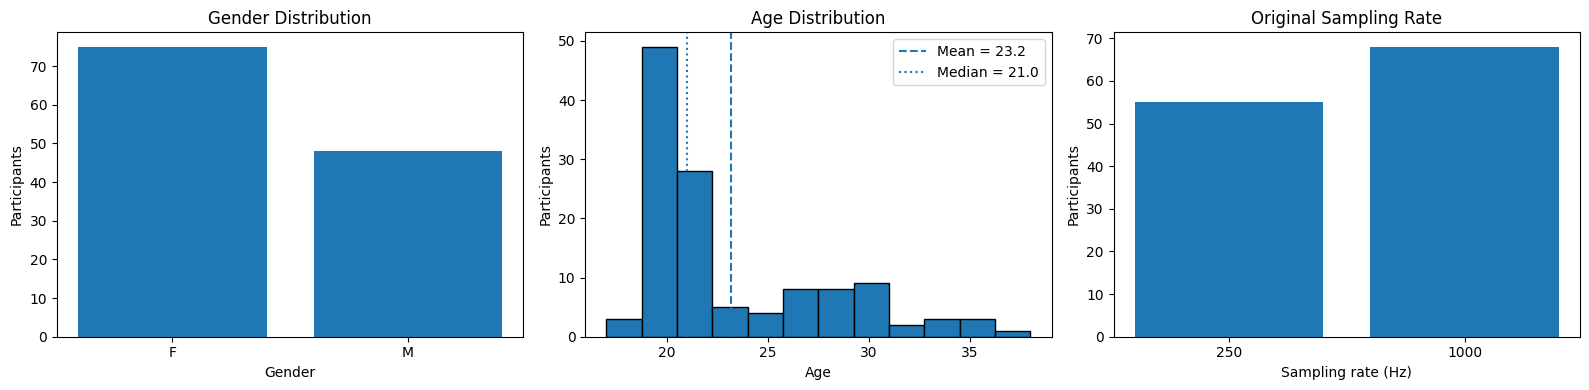

In [88]:
# Cell 19: Plot gender, age, and original sampling-rate distributions

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4),
)

gender_counts = (
    recording_clean["Gender"]
    .astype(str)
    .str.upper()
    .value_counts()
    .sort_index()
)

axes[0].bar(
    gender_counts.index,
    gender_counts.values,
)

axes[0].set_title(
    "Gender Distribution"
)
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Participants")

ages = recording_clean["Age"].dropna()

axes[1].hist(
    ages,
    bins=12,
    edgecolor="black",
)

axes[1].axvline(
    ages.mean(),
    linestyle="--",
    label=f"Mean = {ages.mean():.1f}",
)

axes[1].axvline(
    ages.median(),
    linestyle=":",
    label=f"Median = {ages.median():.1f}",
)

axes[1].set_title(
    "Age Distribution"
)
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Participants")
axes[1].legend()

sampling_counts = (
    recording_clean[
        "Original sampling rate"
    ]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

axes[2].bar(
    sampling_counts.index.astype(str),
    sampling_counts.values,
)

axes[2].set_title(
    "Original Sampling Rate"
)
axes[2].set_xlabel("Sampling rate (Hz)")
axes[2].set_ylabel("Participants")

plt.tight_layout()
plt.show()

In [89]:
# Cell 20: Cross-tabulate cohort and original sampling rate

cohort_sampling_table = pd.crosstab(
    recording_clean["Cohort"],
    recording_clean[
        "Original sampling rate"
    ],
    margins=True,
)

display(cohort_sampling_table)

Original sampling rate,250,1000,All
Cohort,,,
1,55,6,61
2,0,62,62
All,55,68,123


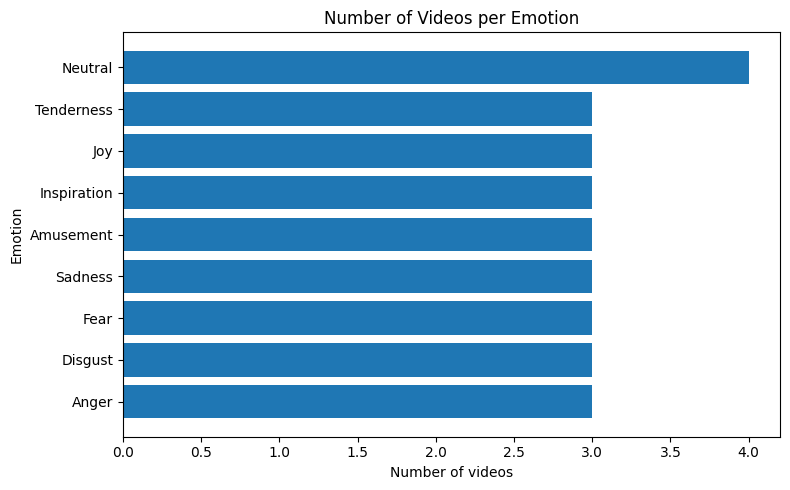

In [90]:
# Cell 21: Plot number of videos for each emotion

emotion_video_counts = (
    video_emotion_df["Emotion"]
    .value_counts()
    .reindex(EXPECTED_EMOTIONS)
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.barh(
    [
        emotion.title()
        for emotion in emotion_video_counts.index
    ],
    emotion_video_counts.values,
)

ax.set_title(
    "Number of Videos per Emotion"
)
ax.set_xlabel("Number of videos")
ax.set_ylabel("Emotion")

plt.tight_layout()
plt.show()

In [91]:
# Cell 22: Summarize stimulus duration and trial count by emotion

stimulus_summary = (
    video_emotion_df
    .groupby("Emotion")["Duration (s)"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max",
    ])
    .reindex(EXPECTED_EMOTIONS)
    .reset_index()
    .rename(columns={
        "count": "Videos",
        "mean": "Mean duration",
        "median": "Median duration",
        "min": "Minimum duration",
        "max": "Maximum duration",
    })
)

stimulus_summary[
    "Subject-video trials"
] = (
    stimulus_summary["Videos"]
    * len(recording_clean)
)

display(stimulus_summary.round(2))

,Emotion,Videos,Mean duration,Median duration,Minimum duration,Maximum duration,Subject-video trials
0,anger,3,72.67,73.0,64.0,81.0,369
1,disgust,3,79.67,79.0,69.0,91.0,369
2,fear,3,74.00,60.0,56.0,106.0,369
3,sadness,3,62.33,60.0,45.0,82.0,369
4,amusement,3,66.33,70.0,56.0,73.0,369
5,inspiration,3,94.00,77.0,76.0,129.0,369
6,joy,3,46.33,37.0,34.0,68.0,369
7,tenderness,3,64.67,63.0,54.0,77.0,369
8,neutral,4,40.25,41.0,35.0,44.0,492


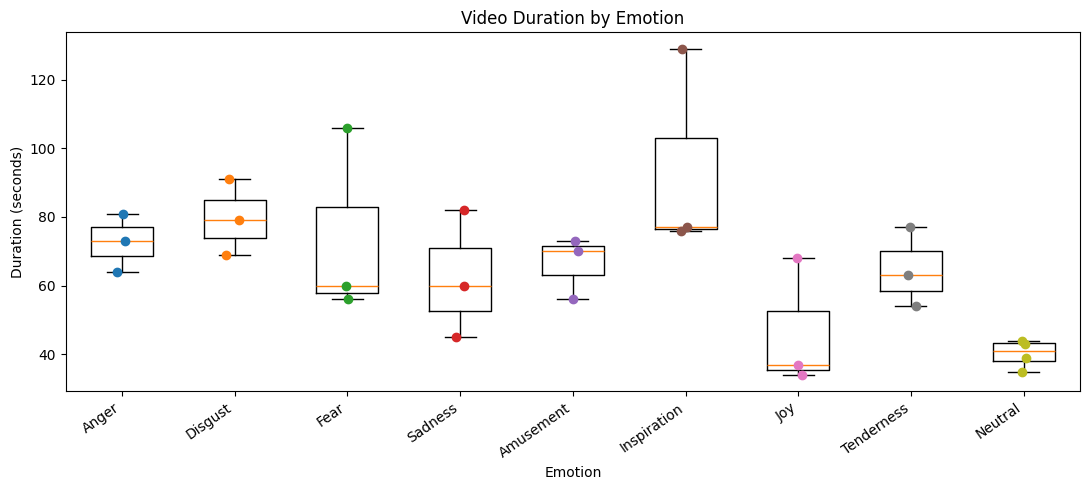

In [92]:
# Cell 23: Plot duration distribution and individual video durations

duration_groups = [
    video_emotion_df.loc[
        video_emotion_df["Emotion"] == emotion,
        "Duration (s)",
    ]
    .dropna()
    .values
    for emotion in EXPECTED_EMOTIONS
]

positions = np.arange(
    len(EXPECTED_EMOTIONS)
)

fig, ax = plt.subplots(
    figsize=(11, 5)
)

ax.boxplot(
    duration_groups,
    positions=positions,
    widths=0.55,
    showfliers=False,
)

random_generator = np.random.default_rng(
    RANDOM_STATE
)

for position, values in zip(
    positions,
    duration_groups,
):
    jitter = random_generator.normal(
        loc=0,
        scale=0.04,
        size=len(values),
    )

    ax.scatter(
        np.full(len(values), position)
        + jitter,
        values,
        zorder=3,
    )

ax.set_xticks(positions)

ax.set_xticklabels(
    [
        emotion.title()
        for emotion in EXPECTED_EMOTIONS
    ],
    rotation=35,
    ha="right",
)

ax.set_title(
    "Video Duration by Emotion"
)
ax.set_xlabel("Emotion")
ax.set_ylabel("Duration (seconds)")

plt.tight_layout()
plt.show()

In [93]:
# Cell 25: Inspect one DE, PSD, and processed EEG array

sample_de = load_pickle_array(
    de_files[0]
)

sample_psd = load_pickle_array(
    psd_files[0]
)

sample_processed = load_pickle_array(
    processed_files[0]
)

sample_arrays = {
    "DE": sample_de,
    "PSD": sample_psd,
    "Processed EEG": sample_processed,
}

sample_statistics = []

for data_type, array in sample_arrays.items():
    sample_statistics.append({
        "Data type": data_type,
        "Shape": str(array.shape),
        "Dtype": str(array.dtype),
        "NaN": int(np.isnan(array).sum()),
        "Inf": int(np.isinf(array).sum()),
        "Minimum": float(np.nanmin(array)),
        "Maximum": float(np.nanmax(array)),
        "Mean": float(np.nanmean(array)),
        "SD": float(np.nanstd(array)),
    })

sample_statistics_df = pd.DataFrame(
    sample_statistics
)

display(sample_statistics_df.round(4))

for data_type, expected_shape in (
    EXPECTED_SHAPES.items()
):
    assert (
        sample_arrays[data_type].shape
        == expected_shape
    )

,Data type,Shape,Dtype,NaN,Inf,Minimum,Maximum,Mean,SD
0,DE,"(28, 32, 30, 5)",float64,0,0,0.4357,6.7083,2.3488,0.5301
1,PSD,"(28, 32, 30, 5)",float64,0,0,0.0000,0.0040,0.0000,0.0000
2,Processed EEG,"(28, 32, 7500)",float64,0,0,-637.0583,904.2260,-0.0000,13.9227


In [94]:
# Cell 26: Define full-file validation function

def validate_array_files(
    files,
    expected_shape,
):
    records = []

    for path in files:
        subject = subject_id_from_path(path)

        try:
            array = load_pickle_array(path)

            records.append({
                "Subject": subject,
                "File": path.name,
                "Shape": tuple(array.shape),
                "Shape valid": (
                    tuple(array.shape)
                    == tuple(expected_shape)
                ),
                "NaN count": int(
                    np.isnan(array).sum()
                ),
                "Inf count": int(
                    np.isinf(array).sum()
                ),
                "All zero": bool(
                    np.all(array == 0)
                ),
                "Load error": None,
            })

        except Exception as error:
            records.append({
                "Subject": subject,
                "File": path.name,
                "Shape": None,
                "Shape valid": False,
                "NaN count": None,
                "Inf count": None,
                "All zero": None,
                "Load error": str(error),
            })

    return pd.DataFrame(records)

In [95]:
# Cell 27: Validate all DE, PSD, and processed EEG files

def validate_array_files(
    files,
    data_name,
    expected_shape,
):
    validation_records = []

    for path in files:
        subject = subject_id_from_path(
            path
        )

        array = load_pickle_array(
            path
        )

        actual_shape = tuple(
            array.shape
        )

        shape_valid = (
            actual_shape
            == tuple(expected_shape)
        )

        numeric_valid = np.issubdtype(
            array.dtype,
            np.number,
        )

        finite_values = np.isfinite(
            array
        )

        finite_count = int(
            finite_values.sum()
        )

        total_values = int(
            array.size
        )

        non_finite_count = (
            total_values
            - finite_count
        )

        validation_records.append({
            "Subject": subject,
            "File": path.name,
            "Data type": data_name,
            "Expected shape": str(
                tuple(expected_shape)
            ),
            "Actual shape": str(
                actual_shape
            ),
            "Shape valid": shape_valid,
            "Numeric array": numeric_valid,
            "Total values": total_values,
            "Finite values": finite_count,
            "Non-finite values": non_finite_count,
            "All finite": (
                non_finite_count == 0
            ),
        })

    validation_df = pd.DataFrame(
        validation_records
    )

    if validation_df.empty:
        raise ValueError(
            f"No {data_name} files were available for validation."
        )

    if not validation_df[
        "Shape valid"
    ].all():
        invalid_rows = validation_df.loc[
            ~validation_df[
                "Shape valid"
            ]
        ]

        display(
            invalid_rows
        )

        raise ValueError(
            f"One or more {data_name} files have unexpected shapes."
        )

    if not validation_df[
        "Numeric array"
    ].all():
        invalid_rows = validation_df.loc[
            ~validation_df[
                "Numeric array"
            ]
        ]

        display(
            invalid_rows
        )

        raise TypeError(
            f"One or more {data_name} files are not numeric arrays."
        )

    return validation_df


de_validation_df = validate_array_files(
    de_files,
    data_name="DE",
    expected_shape=ACTUAL_DE_SHAPE,
)

psd_validation_df = validate_array_files(
    psd_files,
    data_name="PSD",
    expected_shape=ACTUAL_PSD_SHAPE,
)

processed_validation_df = validate_array_files(
    processed_files,
    data_name="Processed EEG",
    expected_shape=ACTUAL_PROCESSED_SHAPE,
)


validation_execution_summary = pd.DataFrame({
    "Data type": [
        "DE",
        "PSD",
        "Processed EEG",
    ],
    "Files validated": [
        len(de_validation_df),
        len(psd_validation_df),
        len(processed_validation_df),
    ],
    "Expected files": [
        len(de_files),
        len(psd_files),
        len(processed_files),
    ],
    "Shape-valid files": [
        int(
            de_validation_df[
                "Shape valid"
            ].sum()
        ),
        int(
            psd_validation_df[
                "Shape valid"
            ].sum()
        ),
        int(
            processed_validation_df[
                "Shape valid"
            ].sum()
        ),
    ],
    "Files with non-finite values": [
        int(
            (
                de_validation_df[
                    "Non-finite values"
                ] > 0
            ).sum()
        ),
        int(
            (
                psd_validation_df[
                    "Non-finite values"
                ] > 0
            ).sum()
        ),
        int(
            (
                processed_validation_df[
                    "Non-finite values"
                ] > 0
            ).sum()
        ),
    ],
    "Validation completed": [
        True,
        True,
        True,
    ],
})

display(
    validation_execution_summary
)

assert (
    validation_execution_summary[
        "Files validated"
    ]
    == validation_execution_summary[
        "Expected files"
    ]
).all(), (
    "Not all discovered files were validated."
)

assert (
    validation_execution_summary[
        "Shape-valid files"
    ]
    == validation_execution_summary[
        "Expected files"
    ]
).all(), (
    "At least one file failed the shape validation."
)

,Data type,Files validated,Expected files,Shape-valid files,Files with non-finite values,Validation completed
0,DE,123,123,123,0,True
1,PSD,123,123,123,0,True
2,Processed EEG,123,123,123,0,True


In [96]:
# Cell 28: Display combined array-integrity summary

def summarize_validation(
    data_type,
    validation_df,
    expected_shape,
):
    required_columns = {
        "Shape valid",
        "Numeric array",
        "Non-finite values",
        "All finite",
    }

    missing_columns = (
        required_columns
        - set(validation_df.columns)
    )

    if missing_columns:
        raise KeyError(
            f"{data_type} validation table is missing columns: "
            f"{sorted(missing_columns)}"
        )

    return {
        "Data type": data_type,
        "Files": len(validation_df),
        "Expected shape": str(
            tuple(expected_shape)
        ),
        "Shape-valid files": int(
            validation_df[
                "Shape valid"
            ].sum()
        ),
        "Shape errors": int(
            (
                ~validation_df[
                    "Shape valid"
                ]
            ).sum()
        ),
        "Numeric files": int(
            validation_df[
                "Numeric array"
            ].sum()
        ),
        "Non-numeric files": int(
            (
                ~validation_df[
                    "Numeric array"
                ]
            ).sum()
        ),
        "Files with non-finite values": int(
            (
                validation_df[
                    "Non-finite values"
                ] > 0
            ).sum()
        ),
        "Total non-finite values": int(
            validation_df[
                "Non-finite values"
            ].sum()
        ),
        "Fully finite files": int(
            validation_df[
                "All finite"
            ].sum()
        ),
        "Validation passed": bool(
            validation_df[
                "Shape valid"
            ].all()
            and validation_df[
                "Numeric array"
            ].all()
        ),
    }


integrity_summary = pd.DataFrame([
    summarize_validation(
        "DE",
        de_validation_df,
        ACTUAL_DE_SHAPE,
    ),
    summarize_validation(
        "PSD",
        psd_validation_df,
        ACTUAL_PSD_SHAPE,
    ),
    summarize_validation(
        "Processed EEG",
        processed_validation_df,
        ACTUAL_PROCESSED_SHAPE,
    ),
])

display(
    integrity_summary
)


# Additional consistency checks
assert integrity_summary[
    "Shape errors"
].sum() == 0, (
    "One or more files failed shape validation."
)

assert integrity_summary[
    "Non-numeric files"
].sum() == 0, (
    "One or more files are not numeric arrays."
)

assert integrity_summary[
    "Validation passed"
].all(), (
    "One or more dataset components failed validation."
)


non_finite_summary = integrity_summary[
    [
        "Data type",
        "Files with non-finite values",
        "Total non-finite values",
    ]
].copy()

display(
    non_finite_summary
)

,Data type,Files,Expected shape,Shape-valid files,Shape errors,Numeric files,Non-numeric files,Files with non-finite values,Total non-finite values,Fully finite files,Validation passed
0,DE,123,"(28, 32, 30, 5)",123,0,123,0,0,0,123,True
1,PSD,123,"(28, 32, 30, 5)",123,0,123,0,0,0,123,True
2,Processed EEG,123,"(28, 32, 7500)",123,0,123,0,0,0,123,True


,Data type,Files with non-finite values,Total non-finite values
0,DE,0,0
1,PSD,0,0
2,Processed EEG,0,0


In [97]:
# Cell 29: Detect completely zero processed EEG channels

zero_channel_records = []

for path in processed_files:
    array = load_pickle_array(path)

    channel_is_zero = np.all(
        array == 0,
        axis=(0, 2),
    )

    zero_channel_indices = np.where(
        channel_is_zero
    )[0]

    for channel_index in zero_channel_indices:
        zero_channel_records.append({
            "Subject": subject_id_from_path(
                path
            ),
            "Channel index": int(
                channel_index
            ),
        })

zero_channel_df = pd.DataFrame(
    zero_channel_records
)

print(
    "All-zero subject-channel cases:",
    len(zero_channel_df),
)

if not zero_channel_df.empty:
    display(zero_channel_df)

All-zero subject-channel cases: 0


In [98]:
###### Cell 30: Select representative subject, video, and channels from actual variability

subject_variability_records = []

for path in processed_files:
    processed_array = load_pickle_array(
        path
    )

    subject_variability_records.append({
        "Path": path,
        "Subject": subject_id_from_path(
            path
        ),
        "Overall SD": float(
            np.nanstd(
                processed_array
            )
        ),
    })

subject_variability_df = pd.DataFrame(
    subject_variability_records
)

dataset_median_subject_sd = (
    subject_variability_df[
        "Overall SD"
    ].median()
)

subject_variability_df[
    "Distance from median"
] = (
    subject_variability_df[
        "Overall SD"
    ]
    - dataset_median_subject_sd
).abs()

representative_row = (
    subject_variability_df
    .sort_values([
        "Distance from median",
        "Subject",
    ])
    .iloc[0]
)

representative_path = (
    representative_row["Path"]
)

representative_subject = (
    representative_row["Subject"]
)

representative_array = (
    load_pickle_array(
        representative_path
    )
)

# Select the video whose overall variability is closest
# to the median video variability for this subject.
video_variability = np.nanstd(
    representative_array,
    axis=(1, 2),
)

median_video_variability = np.nanmedian(
    video_variability
)

representative_video_index = int(
    np.nanargmin(
        np.abs(
            video_variability
            - median_video_variability
        )
    )
)

eeg_trial = representative_array[
    representative_video_index
]

# Select eight channels whose variability is closest
# to the median channel variability within the chosen video.
channel_variability = np.nanstd(
    eeg_trial,
    axis=1,
)

median_channel_variability = np.nanmedian(
    channel_variability
)

selected_channel_indices = (
    np.argsort(
        np.abs(
            channel_variability
            - median_channel_variability
        )
    )[:8]
    .astype(int)
    .tolist()
)

seconds_to_plot = min(
    8,
    int(
        eeg_trial.shape[1]
        / PROCESSED_SAMPLING_RATE
    ),
)

samples_to_plot = (
    seconds_to_plot
    * PROCESSED_SAMPLING_RATE
)

eeg_segment = eeg_trial[
    selected_channel_indices,
    :samples_to_plot,
]

time_axis = (
    np.arange(samples_to_plot)
    / PROCESSED_SAMPLING_RATE
)

selected_channel_labels = [
    electrode_names[channel_index]
    if (
        electrode_names is not None
        and len(electrode_names)
        == eeg_trial.shape[0]
    )
    else f"Channel {channel_index}"
    for channel_index
    in selected_channel_indices
]

representative_selection_summary = pd.DataFrame({
    "Selection item": [
        "Subject",
        "Subject overall SD",
        "Dataset median subject SD",
        "Video index",
        "Video emotion",
        "Video SD",
        "Selected channels",
        "Displayed duration",
    ],
    "Value": [
        representative_subject,
        float(
            representative_row[
                "Overall SD"
            ]
        ),
        float(
            dataset_median_subject_sd
        ),
        representative_video_index + 1,
        video_emotion_df.loc[
            video_emotion_df[
                "Video index"
            ]
            == representative_video_index + 1,
            "Emotion",
        ].iloc[0],
        float(
            video_variability[
                representative_video_index
            ]
        ),
        ", ".join(
            selected_channel_labels
        ),
        f"{seconds_to_plot} seconds",
    ],
})

display(
    representative_selection_summary
)

,Selection item,Value
0,Subject,sub060
1,Subject overall SD,9.112628
2,Dataset median subject SD,9.112628
3,Video index,19
4,Video emotion,amusement
5,Video SD,8.976772
6,Selected channels,"O2, PO4, O1, Oz, PO3, P8, C4, F3"
7,Displayed duration,8 seconds


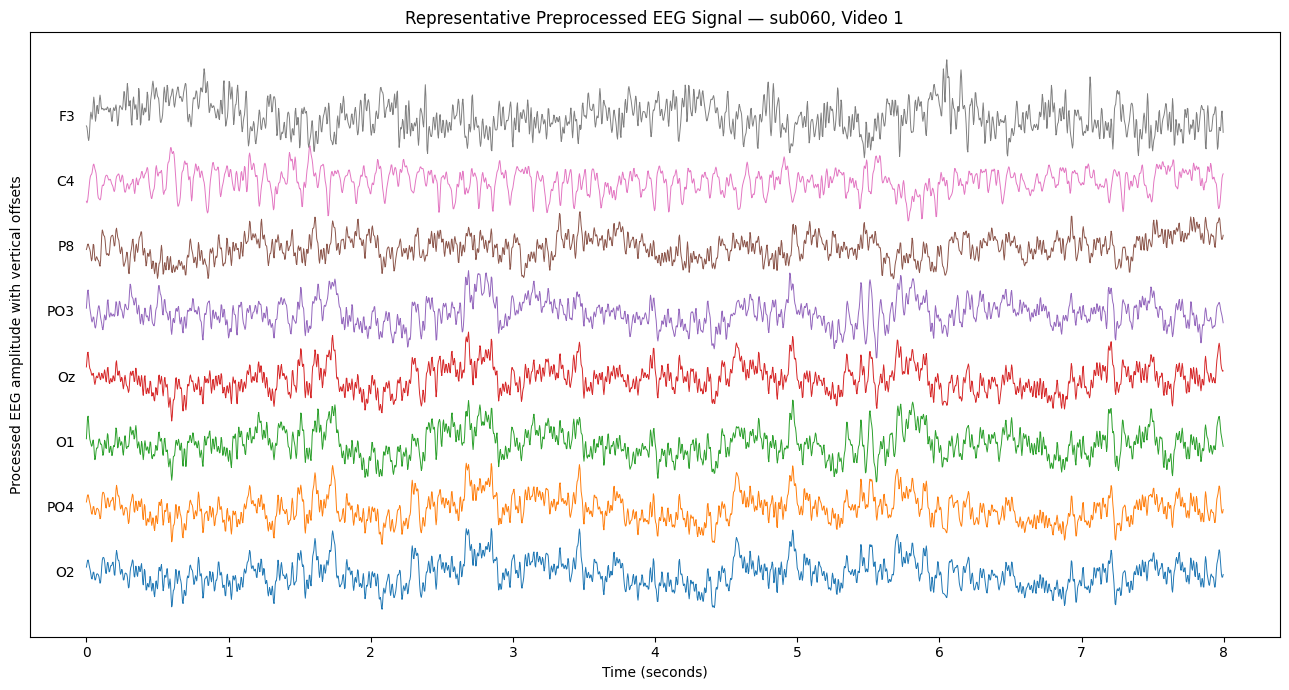

In [99]:
# Cell 31: Plot a representative stacked multichannel EEG waveform

if electrode_names is not None:
    selected_channel_labels = [
        electrode_names[index]
        for index in selected_channel_indices
    ]
else:
    selected_channel_labels = [
        f"Channel {index}"
        for index in selected_channel_indices
    ]

robust_channel_range = (
    np.nanpercentile(
        eeg_segment,
        95,
        axis=1,
    )
    - np.nanpercentile(
        eeg_segment,
        5,
        axis=1,
    )
)

vertical_offset = np.nanmedian(
    robust_channel_range
)

if vertical_offset <= 0:
    vertical_offset = 1.0
else:
    vertical_offset *= 1.5

fig, ax = plt.subplots(
    figsize=(13, 7)
)

for row_index, signal in enumerate(
    eeg_segment
):
    ax.plot(
        time_axis,
        signal
        + row_index * vertical_offset,
        linewidth=0.7,
    )

    ax.text(
        -0.08,
        row_index * vertical_offset,
        selected_channel_labels[
            row_index
        ],
        ha="right",
        va="center",
    )

ax.set_title(
    "Representative Preprocessed EEG Signal — "
    f"{representative_subject}, Video 1"
)

ax.set_xlabel("Time (seconds)")
ax.set_ylabel(
    "Processed EEG amplitude with vertical offsets"
)
ax.set_yticks([])

plt.tight_layout()
plt.show()

In [100]:
# Cell 32: Calculate statistics for representative EEG channels

representative_statistics = []

for row_index, channel_index in enumerate(
    selected_channel_indices
):
    signal = eeg_segment[row_index]

    channel_label = (
        electrode_names[channel_index]
        if electrode_names is not None
        else f"Channel {channel_index}"
    )

    signal_mean = float(
        np.nanmean(signal)
    )

    signal_sd = float(
        np.nanstd(signal)
    )

    signal_median = float(
        np.nanmedian(signal)
    )

    signal_mad = float(
        median_abs_deviation(
            signal,
            nan_policy="omit",
        )
    )

    signal_minimum = float(
        np.nanmin(signal)
    )

    signal_maximum = float(
        np.nanmax(signal)
    )

    signal_peak_to_peak = (
        signal_maximum
        - signal_minimum
    )

    signal_rms = float(
        np.sqrt(
            np.nanmean(signal ** 2)
        )
    )

    representative_statistics.append({
        "Channel": channel_label,
        "Mean": signal_mean,
        "SD": signal_sd,
        "Median": signal_median,
        "MAD": signal_mad,
        "Minimum": signal_minimum,
        "Maximum": signal_maximum,
        "Peak-to-peak": signal_peak_to_peak,
        "RMS": signal_rms,
    })

representative_statistics_df = pd.DataFrame(
    representative_statistics
)

display(
    representative_statistics_df.round(4)
)

,Channel,Mean,SD,Median,MAD,Minimum,Maximum,Peak-to-peak,RMS
0,O2,-0.5099,6.3913,-0.8356,4.4275,-17.5388,21.1325,38.6714,6.4116
1,PO4,-0.5010,6.3716,-0.8132,4.3745,-17.6122,21.3113,38.9235,6.3913
2,O1,-0.3935,6.6795,-0.8248,4.3624,-18.8852,20.3906,39.2758,6.6911
3,Oz,-0.5487,6.3763,-0.9123,4.0844,-20.8651,21.8203,42.6854,6.3999
4,PO3,-0.2742,6.2803,-0.3381,4.0303,-21.7805,20.0866,41.8671,6.2862
5,P8,-0.0420,5.6446,0.0505,4.0078,-15.0836,17.1128,32.1964,5.6447
6,C4,0.4810,5.5536,0.9723,3.7113,-18.5401,17.5312,36.0713,5.5743
7,F3,0.2085,7.1126,-0.0494,4.8598,-19.3843,27.5843,46.9686,7.1157


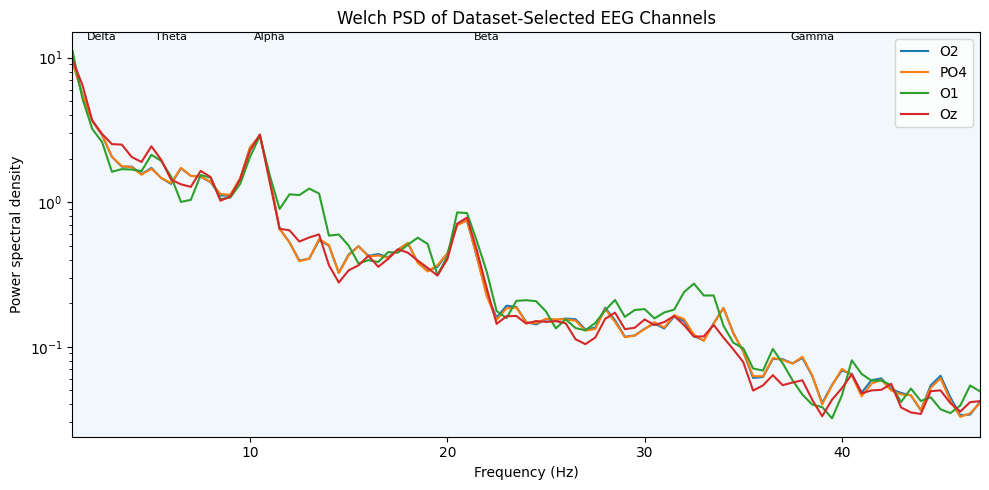

In [101]:
# Cell 33: Plot Welch PSD using FACED dataset frequency-band definitions

# FACED DE/PSD features use:
# Delta 1–4 Hz
# Theta 4–8 Hz
# Alpha 8–14 Hz
# Beta 14–30 Hz
# Gamma 30–47 Hz

FACED_BAND_RANGES = {
    "Delta": (1, 4),
    "Theta": (4, 8),
    "Alpha": (8, 14),
    "Beta": (14, 30),
    "Gamma": (30, 47),
}

# Use up to four channels from the dataset-driven selection in Cell 30.
welch_channel_indices = (
    selected_channel_indices[:4]
)

fig, ax = plt.subplots(
    figsize=(10, 5)
)

for channel_index in welch_channel_indices:
    frequencies, power = welch(
        eeg_trial[
            channel_index
        ],
        fs=PROCESSED_SAMPLING_RATE,
        nperseg=min(
            PROCESSED_SAMPLING_RATE * 2,
            eeg_trial.shape[1],
        ),
    )

    valid_frequency_mask = (
        (frequencies >= 1)
        & (frequencies <= 47)
    )

    channel_label = (
        electrode_names[
            channel_index
        ]
        if (
            electrode_names is not None
            and len(electrode_names)
            == eeg_trial.shape[0]
        )
        else f"Channel {channel_index}"
    )

    ax.semilogy(
        frequencies[
            valid_frequency_mask
        ],
        power[
            valid_frequency_mask
        ] + np.finfo(float).eps,
        label=channel_label,
    )

for band_name, (
    lower_frequency,
    upper_frequency,
) in FACED_BAND_RANGES.items():
    ax.axvspan(
        lower_frequency,
        upper_frequency,
        alpha=0.06,
    )

    ax.text(
        (
            lower_frequency
            + upper_frequency
        ) / 2,
        ax.get_ylim()[1],
        band_name,
        ha="center",
        va="top",
        fontsize=8,
    )

ax.set_title(
    "Welch PSD of Dataset-Selected EEG Channels"
)

ax.set_xlabel(
    "Frequency (Hz)"
)

ax.set_ylabel(
    "Power spectral density"
)

ax.set_xlim(
    1,
    47,
)

ax.legend()

plt.tight_layout()
plt.show()

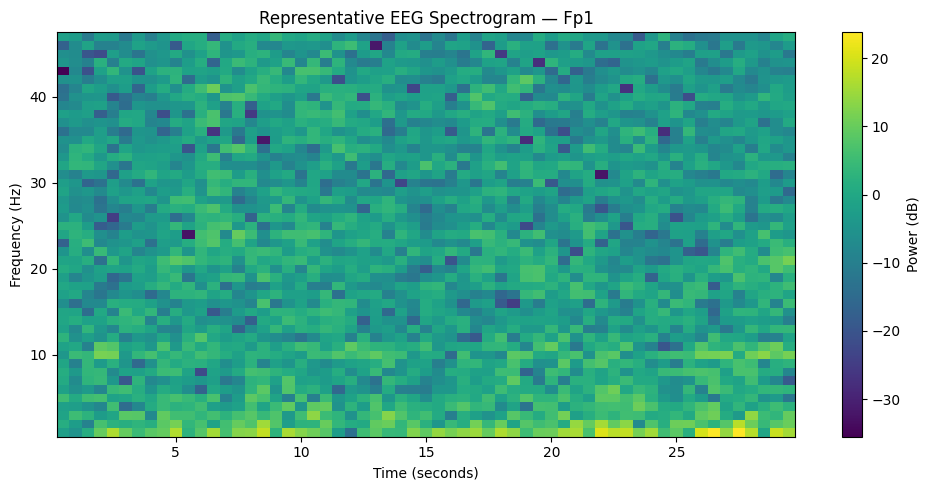

In [102]:
# Cell 34: Plot one representative EEG spectrogram

spectrogram_channel_index = 0

frequencies, times, spectral_power = (
    spectrogram(
        eeg_trial[
            spectrogram_channel_index
        ],
        fs=PROCESSED_SAMPLING_RATE,
        nperseg=PROCESSED_SAMPLING_RATE,
        noverlap=(
            PROCESSED_SAMPLING_RATE // 2
        ),
    )
)

valid_frequency_mask = (
    (frequencies >= 1)
    & (frequencies <= 47)
)

spectrogram_channel_label = (
    electrode_names[
        spectrogram_channel_index
    ]
    if electrode_names is not None
    else (
        f"Channel "
        f"{spectrogram_channel_index}"
    )
)

fig, ax = plt.subplots(
    figsize=(10, 5)
)

mesh = ax.pcolormesh(
    times,
    frequencies[
        valid_frequency_mask
    ],
    10 * np.log10(
        spectral_power[
            valid_frequency_mask
        ] + 1e-20
    ),
    shading="auto",
)

ax.set_title(
    "Representative EEG Spectrogram — "
    f"{spectrogram_channel_label}"
)
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Frequency (Hz)")

fig.colorbar(
    mesh,
    ax=ax,
    label="Power (dB)",
)

plt.tight_layout()
plt.show()

In [103]:
# Cell 35: Define Hjorth activity, mobility, and complexity

def calculate_hjorth_parameters(signal):
    signal = np.asarray(
        signal,
        dtype=float,
    )

    first_difference = np.diff(signal)
    second_difference = np.diff(
        first_difference
    )

    activity = np.var(signal)

    first_variance = np.var(
        first_difference
    )

    second_variance = np.var(
        second_difference
    )

    if activity <= 0:
        mobility = 0.0
    else:
        mobility = np.sqrt(
            first_variance / activity
        )

    if (
        first_variance <= 0
        or mobility <= 0
    ):
        complexity = 0.0
    else:
        derivative_mobility = np.sqrt(
            second_variance
            / first_variance
        )

        complexity = (
            derivative_mobility
            / mobility
        )

    return (
        float(activity),
        float(mobility),
        float(complexity),
    )

In [104]:
# Cell 36: Load or calculate processed EEG signal features with cache validation

SIGNAL_FEATURE_CACHE = Path(
    "/kaggle/working/faced_processed_signal_features.pkl"
)

required_signal_feature_columns = [
    "Subject",
    "Video index",
    "Channel index",
    "Mean",
    "SD",
    "MAD",
    "Peak-to-peak",
    "RMS",
    "Hjorth activity",
    "Hjorth mobility",
    "Hjorth complexity",
]

expected_feature_rows = (
    len(processed_files)
    * ACTUAL_VIDEOS
    * ACTUAL_CHANNELS
)

current_subjects = sorted(
    processed_subjects
)

use_cached_features = False

if SIGNAL_FEATURE_CACHE.exists():
    cached_signal_features = pd.read_pickle(
        SIGNAL_FEATURE_CACHE
    )

    cached_columns_valid = set(
        required_signal_feature_columns
    ).issubset(
        cached_signal_features.columns
    )

    cached_row_count_valid = (
        len(cached_signal_features)
        == expected_feature_rows
    )

    cached_subjects = sorted(
        cached_signal_features[
            "Subject"
        ]
        .astype(str)
        .unique()
        .tolist()
    )

    cached_subjects_valid = (
        cached_subjects
        == current_subjects
    )

    cached_video_count_valid = (
        cached_signal_features[
            "Video index"
        ].nunique()
        == ACTUAL_VIDEOS
    )

    cached_channel_count_valid = (
        cached_signal_features[
            "Channel index"
        ].nunique()
        == ACTUAL_CHANNELS
    )

    use_cached_features = all([
        cached_columns_valid,
        cached_row_count_valid,
        cached_subjects_valid,
        cached_video_count_valid,
        cached_channel_count_valid,
    ])

    if use_cached_features:
        signal_features_df = (
            cached_signal_features[
                required_signal_feature_columns
            ].copy()
        )

        print(
            "Loaded validated signal-feature cache:",
            SIGNAL_FEATURE_CACHE,
        )

    else:
        print(
            "Existing cache does not match the current dataset. "
            "Signal features will be recomputed."
        )


if not use_cached_features:
    signal_feature_records = []

    total_subjects = len(
        processed_files
    )

    for subject_number, path in enumerate(
        processed_files,
        start=1,
    ):
        subject = subject_id_from_path(
            path
        )

        array = load_pickle_array(
            path
        )

        if array.shape != (
            ACTUAL_VIDEOS,
            ACTUAL_CHANNELS,
            ACTUAL_SAMPLES_PER_TRIAL,
        ):
            raise ValueError(
                f"Unexpected processed EEG shape in {path.name}: "
                f"{array.shape}"
            )

        for video_index in range(
            array.shape[0]
        ):
            for channel_index in range(
                array.shape[1]
            ):
                signal = np.asarray(
                    array[
                        video_index,
                        channel_index,
                    ],
                    dtype=float,
                )

                activity, mobility, complexity = (
                    calculate_hjorth_parameters(
                        signal
                    )
                )

                signal_minimum = float(
                    np.nanmin(signal)
                )

                signal_maximum = float(
                    np.nanmax(signal)
                )

                signal_feature_records.append({
                    "Subject": subject,
                    "Video index": video_index + 1,
                    "Channel index": channel_index,
                    "Mean": float(
                        np.nanmean(signal)
                    ),
                    "SD": float(
                        np.nanstd(signal)
                    ),
                    "MAD": float(
                        median_abs_deviation(
                            signal,
                            nan_policy="omit",
                        )
                    ),
                    "Peak-to-peak": (
                        signal_maximum
                        - signal_minimum
                    ),
                    "RMS": float(
                        np.sqrt(
                            np.nanmean(
                                signal ** 2
                            )
                        )
                    ),
                    "Hjorth activity": activity,
                    "Hjorth mobility": mobility,
                    "Hjorth complexity": complexity,
                })

        if (
            subject_number == 1
            or subject_number % 10 == 0
            or subject_number == total_subjects
        ):
            print(
                f"Processed {subject_number}/{total_subjects} subjects"
            )

    signal_features_df = pd.DataFrame(
        signal_feature_records
    )

    assert len(
        signal_features_df
    ) == expected_feature_rows, (
        f"Expected {expected_feature_rows} feature rows, "
        f"found {len(signal_features_df)}."
    )

    assert sorted(
        signal_features_df[
            "Subject"
        ].unique()
    ) == current_subjects

    signal_features_df.to_pickle(
        SIGNAL_FEATURE_CACHE
    )

    print(
        "Saved validated signal features to:",
        SIGNAL_FEATURE_CACHE,
    )

print(
    "Signal-feature rows:",
    len(signal_features_df),
)

Loaded validated signal-feature cache: /kaggle/working/faced_processed_signal_features.pkl
Signal-feature rows: 110208


In [105]:
# Cell 37: Display overall processed EEG feature statistics

signal_feature_columns = [
    "Mean",
    "SD",
    "MAD",
    "Peak-to-peak",
    "RMS",
    "Hjorth activity",
    "Hjorth mobility",
    "Hjorth complexity",
]

signal_feature_summary = (
    signal_features_df[
        signal_feature_columns
    ]
    .describe()
    .T[
        [
            "count",
            "mean",
            "std",
            "50%",
            "min",
            "max",
        ]
    ]
    .rename(columns={
        "50%": "median",
    })
    .reset_index(
        names="Feature",
    )
)

display(
    signal_feature_summary.round(4)
)

,Feature,count,mean,std,median,min,max
0,Mean,110208.0,0.000000e+00,2.931380e+01,-0.0008,-3140.4822,4.270203e+03
1,SD,110208.0,9.421710e+01,2.392107e+03,6.5278,1.7421,1.640340e+05
2,MAD,110208.0,8.030630e+01,2.366011e+03,4.1305,1.1851,1.862571e+05
3,Peak-to-peak,110208.0,4.448820e+02,9.333355e+03,52.2227,13.1649,6.148781e+05
4,RMS,110208.0,9.422550e+01,2.392286e+03,6.5291,1.7421,1.640407e+05
5,Hjorth activity,110208.0,5.730999e+06,3.411673e+08,42.6124,3.0348,2.690716e+10
6,Hjorth mobility,110208.0,3.502000e-01,1.752000e-01,0.3101,0.0157,1.176000e+00
7,Hjorth complexity,110208.0,3.016200e+00,1.694200e+00,2.7030,1.0002,5.047600e+01


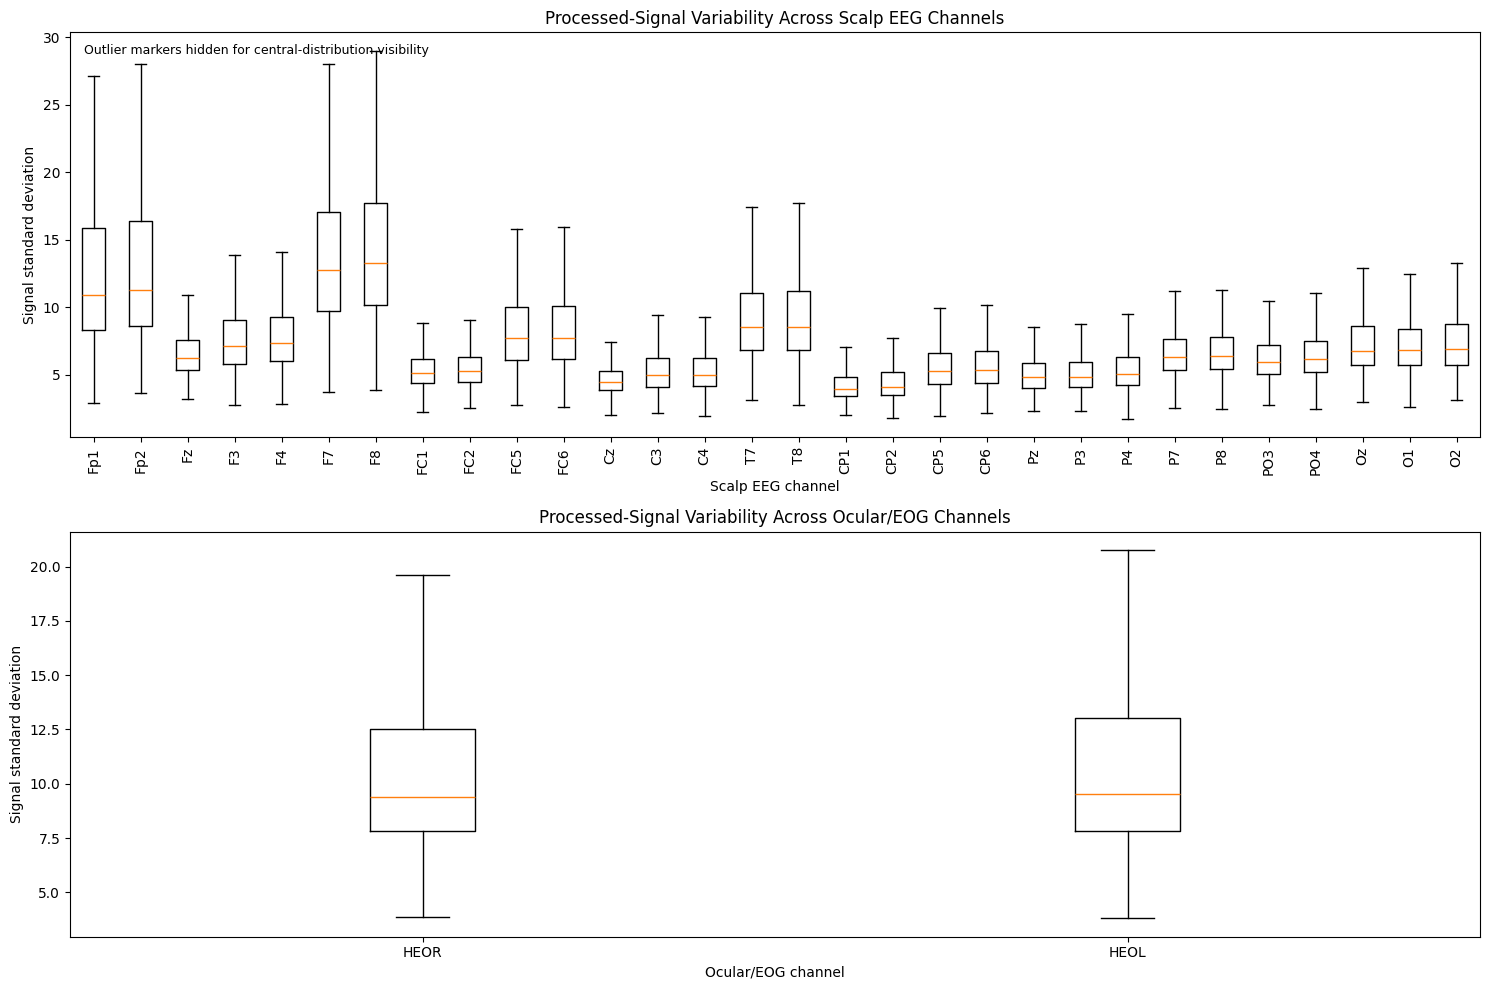

,Metric,Value
0,Signal-feature rows,110208
1,Rows matched to channel metadata,110208
2,Scalp EEG channels,30
3,Ocular/EOG channels,2


In [106]:
# Cell 38: Attach channel metadata and compare variability by channel type

required_signal_columns = {
    "Subject",
    "Video index",
    "Channel index",
    "SD",
}

missing_signal_columns = (
    required_signal_columns
    - set(signal_features_df.columns)
)

if missing_signal_columns:
    raise KeyError(
        "signal_features_df is missing required columns: "
        f"{sorted(missing_signal_columns)}"
    )


required_channel_columns = {
    "Channel index",
    "Channel number",
    "Channel label",
    "Channel type",
}

missing_channel_columns = (
    required_channel_columns
    - set(channel_metadata_df.columns)
)

if missing_channel_columns:
    raise KeyError(
        "channel_metadata_df is missing required columns: "
        f"{sorted(missing_channel_columns)}"
    )


assert channel_metadata_df[
    "Channel index"
].is_unique, (
    "Channel index is not unique in channel_metadata_df."
)

assert len(channel_metadata_df) == ACTUAL_CHANNELS, (
    f"Channel metadata contains {len(channel_metadata_df)} channels, "
    f"but processed EEG contains {ACTUAL_CHANNELS}."
)


signal_features_with_channel_info = (
    signal_features_df
    .merge(
        channel_metadata_df[
            [
                "Channel index",
                "Channel number",
                "Channel label",
                "Channel type",
            ]
        ],
        on="Channel index",
        how="left",
        validate="many_to_one",
    )
)


assert len(
    signal_features_with_channel_info
) == len(signal_features_df), (
    "Channel-metadata merge changed the number of signal-feature rows."
)

assert signal_features_with_channel_info[
    [
        "Channel number",
        "Channel label",
        "Channel type",
    ]
].notna().all().all(), (
    "Some signal-feature rows could not be matched "
    "to channel metadata."
)


scalp_signal_features = (
    signal_features_with_channel_info.loc[
        signal_features_with_channel_info[
            "Channel type"
        ] == "Scalp EEG"
    ]
    .copy()
)

ocular_signal_features = (
    signal_features_with_channel_info.loc[
        signal_features_with_channel_info[
            "Channel type"
        ] == "Ocular/EOG"
    ]
    .copy()
)


scalp_channel_metadata = (
    channel_metadata_df.loc[
        channel_metadata_df[
            "Channel type"
        ] == "Scalp EEG"
    ]
    .sort_values("Channel index")
    .copy()
)

ocular_channel_metadata = (
    channel_metadata_df.loc[
        channel_metadata_df[
            "Channel type"
        ] == "Ocular/EOG"
    ]
    .sort_values("Channel index")
    .copy()
)


scalp_labels = (
    scalp_channel_metadata[
        "Channel label"
    ]
    .tolist()
)

ocular_labels = (
    ocular_channel_metadata[
        "Channel label"
    ]
    .tolist()
)

scalp_channel_indices = (
    scalp_channel_metadata[
        "Channel index"
    ]
    .astype(int)
    .tolist()
)

ocular_channel_indices = (
    ocular_channel_metadata[
        "Channel index"
    ]
    .astype(int)
    .tolist()
)


assert len(scalp_labels) > 0, (
    "No scalp EEG channels were identified."
)

assert (
    len(scalp_labels)
    + len(ocular_labels)
    == ACTUAL_CHANNELS
), (
    "Scalp and ocular channel counts do not match "
    "the processed EEG channel count."
)


scalp_sd_groups = [
    scalp_signal_features.loc[
        scalp_signal_features[
            "Channel label"
        ] == label,
        "SD",
    ]
    .dropna()
    .values
    for label in scalp_labels
]

ocular_sd_groups = [
    ocular_signal_features.loc[
        ocular_signal_features[
            "Channel label"
        ] == label,
        "SD",
    ]
    .dropna()
    .values
    for label in ocular_labels
]


fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 10),
)


axes[0].boxplot(
    scalp_sd_groups,
    tick_labels=scalp_labels,
    showfliers=False,
)

axes[0].set_title(
    "Processed-Signal Variability Across Scalp EEG Channels"
)

axes[0].set_xlabel(
    "Scalp EEG channel"
)

axes[0].set_ylabel(
    "Signal standard deviation"
)

axes[0].tick_params(
    axis="x",
    rotation=90,
)

axes[0].text(
    0.01,
    0.97,
    "Outlier markers hidden for central-distribution visibility",
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=9,
)


if ocular_labels:
    axes[1].boxplot(
        ocular_sd_groups,
        tick_labels=ocular_labels,
        showfliers=False,
    )

    axes[1].set_title(
        "Processed-Signal Variability Across Ocular/EOG Channels"
    )

    axes[1].set_xlabel(
        "Ocular/EOG channel"
    )

    axes[1].set_ylabel(
        "Signal standard deviation"
    )

else:
    axes[1].text(
        0.5,
        0.5,
        "No ocular/EOG channels were identified.",
        ha="center",
        va="center",
    )

    axes[1].axis("off")


plt.tight_layout()
plt.show()


channel_merge_summary = pd.DataFrame({
    "Metric": [
        "Signal-feature rows",
        "Rows matched to channel metadata",
        "Scalp EEG channels",
        "Ocular/EOG channels",
    ],
    "Value": [
        len(signal_features_df),
        int(
            signal_features_with_channel_info[
                "Channel label"
            ].notna().sum()
        ),
        len(scalp_labels),
        len(ocular_labels),
    ],
})

display(channel_merge_summary)

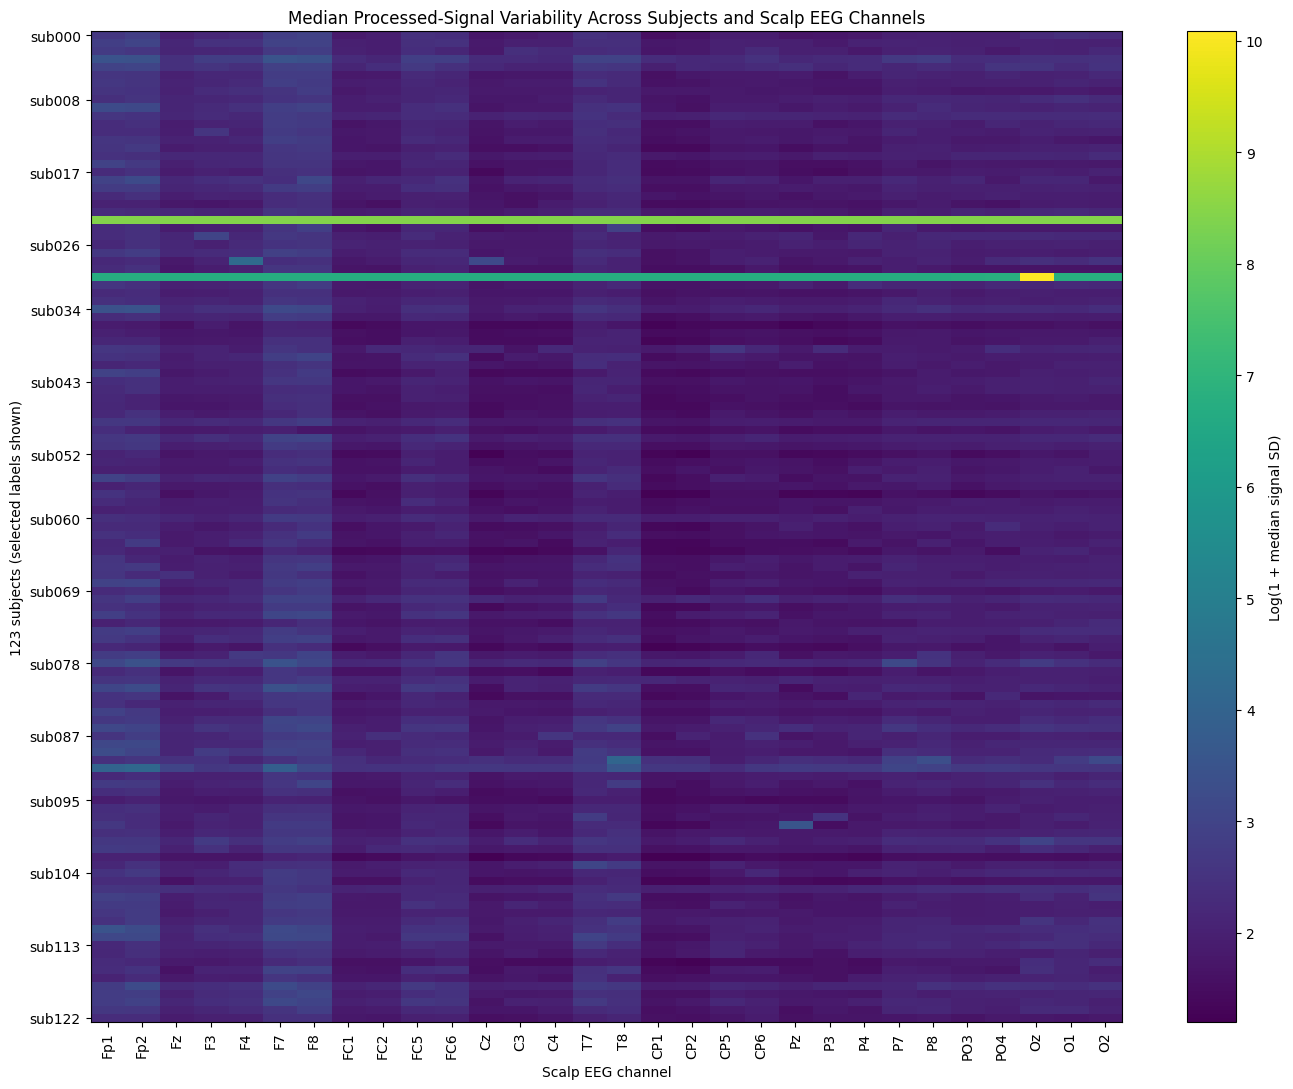

In [107]:
# Cell 39: Plot readable subject-by-scalp-channel variability heatmap

scalp_subject_channel_sd = (
    scalp_signal_features
    .groupby([
        "Subject",
        "Channel label",
    ])["SD"]
    .median()
    .unstack("Channel label")
    .reindex(
        columns=scalp_labels
    )
    .sort_index()
)


assert scalp_subject_channel_sd.shape[0] == len(
    processed_subjects
), (
    "The scalp-channel heatmap does not contain "
    "the expected number of subjects."
)

assert scalp_subject_channel_sd.shape[1] == len(
    scalp_labels
), (
    "The scalp-channel heatmap does not contain "
    "the expected number of scalp channels."
)


# Log transformation improves visibility without changing
# the underlying signal-feature table.
scalp_subject_channel_log_sd = np.log1p(
    scalp_subject_channel_sd
)


fig, ax = plt.subplots(
    figsize=(14, 11)
)

image = ax.imshow(
    scalp_subject_channel_log_sd.values,
    aspect="auto",
)

ax.set_xticks(
    np.arange(
        len(scalp_labels)
    )
)

ax.set_xticklabels(
    scalp_labels,
    rotation=90,
)

number_of_subjects = (
    scalp_subject_channel_log_sd.shape[0]
)

visible_subject_positions = np.unique(
    np.linspace(
        0,
        number_of_subjects - 1,
        min(15, number_of_subjects),
        dtype=int,
    )
)

ax.set_yticks(
    visible_subject_positions
)

ax.set_yticklabels(
    scalp_subject_channel_log_sd.index[
        visible_subject_positions
    ]
)

ax.set_xlabel(
    "Scalp EEG channel"
)

ax.set_ylabel(
    f"{number_of_subjects} subjects "
    "(selected labels shown)"
)

ax.set_title(
    "Median Processed-Signal Variability Across "
    "Subjects and Scalp EEG Channels"
)

fig.colorbar(
    image,
    ax=ax,
    label="Log(1 + median signal SD)",
)

plt.tight_layout()
plt.show()

In [108]:
# Cell 40: Quantify channel-specific high-variability records

required_columns = {
    "Subject",
    "Video index",
    "Channel index",
    "Channel number",
    "Channel label",
    "Channel type",
    "SD",
    "MAD",
    "Peak-to-peak",
}

missing_columns = (
    required_columns
    - set(signal_features_with_channel_info.columns)
)

if missing_columns:
    raise KeyError(
        "signal_features_with_channel_info is missing columns: "
        f"{sorted(missing_columns)}"
    )


high_variability_df = (
    signal_features_with_channel_info
    .copy()
)


# ------------------------------------------------------------
# Calculate a separate threshold for every channel
# ------------------------------------------------------------

channel_thresholds = (
    high_variability_df
    .groupby(
        [
            "Channel index",
            "Channel number",
            "Channel label",
            "Channel type",
        ]
    )["SD"]
    .agg(
        Q1=lambda values: values.quantile(0.25),
        Q3=lambda values: values.quantile(0.75),
    )
    .reset_index()
)


channel_thresholds[
    "IQR"
] = (
    channel_thresholds["Q3"]
    - channel_thresholds["Q1"]
)


channel_thresholds[
    "High-variability threshold"
] = (
    channel_thresholds["Q3"]
    + 3 * channel_thresholds["IQR"]
)


high_variability_df = (
    high_variability_df
    .merge(
        channel_thresholds[
            [
                "Channel index",
                "High-variability threshold",
            ]
        ],
        on="Channel index",
        how="left",
        validate="many_to_one",
    )
)


assert high_variability_df[
    "High-variability threshold"
].notna().all(), (
    "Some records did not receive a channel-specific threshold."
)


high_variability_df[
    "High variability"
] = (
    high_variability_df["SD"]
    >
    high_variability_df[
        "High-variability threshold"
    ]
)


high_variability_records = (
    high_variability_df.loc[
        high_variability_df[
            "High variability"
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# Overall summary
# ------------------------------------------------------------

variability_summary = pd.DataFrame({
    "Metric": [
        "Total subject-video-channel records",
        "High-variability records",
        "Subjects with high-variability records",
        "Scalp EEG channels affected",
        "Ocular/EOG channels affected",
    ],
    "Value": [
        len(high_variability_df),
        len(high_variability_records),
        high_variability_records[
            "Subject"
        ].nunique(),
        high_variability_records.loc[
            high_variability_records[
                "Channel type"
            ] == "Scalp EEG",
            "Channel label",
        ].nunique(),
        high_variability_records.loc[
            high_variability_records[
                "Channel type"
            ] == "Ocular/EOG",
            "Channel label",
        ].nunique(),
    ],
})


print("Channel-specific variability thresholds")

display(
    channel_thresholds.round(4)
)


print("Overall high-variability summary")

display(
    variability_summary
)


# ------------------------------------------------------------
# Channel-level summary
# ------------------------------------------------------------

channel_variability_summary = (
    high_variability_df
    .groupby(
        [
            "Channel index",
            "Channel number",
            "Channel label",
            "Channel type",
        ],
        as_index=False,
    )
    .agg(
        Records=(
            "SD",
            "size",
        ),
        High_variability_records=(
            "High variability",
            "sum",
        ),
        Median_SD=(
            "SD",
            "median",
        ),
        Maximum_SD=(
            "SD",
            "max",
        ),
        Median_peak_to_peak=(
            "Peak-to-peak",
            "median",
        ),
        Maximum_peak_to_peak=(
            "Peak-to-peak",
            "max",
        ),
    )
)


subjects_affected_by_channel = (
    high_variability_records
    .groupby(
        [
            "Channel index",
            "Channel number",
            "Channel label",
            "Channel type",
        ]
    )["Subject"]
    .nunique()
    .rename("Subjects_affected")
    .reset_index()
)


channel_variability_summary = (
    channel_variability_summary
    .merge(
        subjects_affected_by_channel,
        on=[
            "Channel index",
            "Channel number",
            "Channel label",
            "Channel type",
        ],
        how="left",
        validate="one_to_one",
    )
)


channel_variability_summary[
    "Subjects_affected"
] = (
    channel_variability_summary[
        "Subjects_affected"
    ]
    .fillna(0)
    .astype(int)
)


channel_variability_summary = (
    channel_variability_summary
    .merge(
        channel_thresholds[
            [
                "Channel index",
                "High-variability threshold",
            ]
        ],
        on="Channel index",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        [
            "High_variability_records",
            "Maximum_SD",
        ],
        ascending=False,
    )
)


print("Channel-level variability summary")

display(
    channel_variability_summary.round(4)
)


# ------------------------------------------------------------
# Largest individual records
# ------------------------------------------------------------

print(
    "Largest channel-specific high-variability records"
)

display(
    high_variability_records[
        [
            "Subject",
            "Video index",
            "Channel index",
            "Channel number",
            "Channel label",
            "Channel type",
            "SD",
            "MAD",
            "Peak-to-peak",
            "High-variability threshold",
        ]
    ]
    .sort_values(
        "SD",
        ascending=False,
    )
    .head(30)
    .round(4)
)

Channel-specific variability thresholds


,Channel index,Channel number,Channel label,Channel type,Q1,Q3,IQR,High-variability threshold
0,0,1,Fp1,Scalp EEG,8.3213,15.8626,7.5413,38.4866
1,1,2,Fp2,Scalp EEG,8.6245,16.3922,7.7677,39.6953
2,2,3,Fz,Scalp EEG,5.3439,7.5749,2.2310,14.2678
3,3,4,F3,Scalp EEG,5.8203,9.0410,3.2207,18.7030
4,4,5,F4,Scalp EEG,6.0148,9.2546,3.2398,18.9738
5,5,6,F7,Scalp EEG,9.7232,17.0588,7.3356,39.0658
6,6,7,F8,Scalp EEG,10.1579,17.7565,7.5986,40.5522
7,7,8,FC1,Scalp EEG,4.3838,6.1619,1.7781,11.4963
8,8,9,FC2,Scalp EEG,4.4560,6.2894,1.8334,11.7897
9,9,10,FC5,Scalp EEG,6.1323,9.9904,3.8581,21.5647


Overall high-variability summary


,Metric,Value
0,Total subject-video-channel records,110208
1,High-variability records,5009
2,Subjects with high-variability records,97
3,Scalp EEG channels affected,30
4,Ocular/EOG channels affected,2


Channel-level variability summary


,Channel index,Channel number,Channel label,Channel type,Records,High_variability_records,Median_SD,Maximum_SD,Median_peak_to_peak,Maximum_peak_to_peak,Subjects_affected,High-variability threshold
31,31,32,HEOL,Ocular/EOG,3444,265,9.5512,164034.0208,75.7765,614878.1345,46,28.5715
30,30,31,HEOR,Ocular/EOG,3444,228,9.3929,10899.9171,74.2842,40043.6122,43,26.7000
11,11,12,Cz,Scalp EEG,3444,219,4.4987,5291.6115,34.1459,19841.8553,39,9.6473
24,24,25,P8,Scalp EEG,3444,206,6.3603,5292.4365,50.8233,19842.1821,43,14.8842
16,16,17,CP1,Scalp EEG,3444,205,3.9325,5291.7598,30.3268,19844.7985,39,9.2301
20,20,21,Pz,Scalp EEG,3444,185,4.8081,5291.9589,37.4352,19838.3339,37,11.3297
23,23,24,P7,Scalp EEG,3444,185,6.3498,5291.4201,50.5325,19851.9018,37,14.7560
17,17,18,CP2,Scalp EEG,3444,182,4.0961,5290.9142,31.6127,19832.8884,39,10.2723
8,8,9,FC2,Scalp EEG,3444,176,5.2936,5290.3449,40.1387,19819.6624,39,11.7897
1,1,2,Fp2,Scalp EEG,3444,169,11.2744,5291.3786,91.2119,19806.8562,34,39.6953


Largest channel-specific high-variability records


,Subject,Video index,Channel index,Channel number,Channel label,Channel type,SD,MAD,Peak-to-peak,High-variability threshold
21407,sub023,25,31,32,HEOL,Ocular/EOG,164034.0208,161112.2921,556936.5827,28.5715
21279,sub023,21,31,32,HEOL,Ocular/EOG,163126.6725,160823.7253,556575.5310,28.5715
21311,sub023,22,31,32,HEOL,Ocular/EOG,163114.2898,161425.8621,547284.9324,28.5715
21375,sub023,24,31,32,HEOL,Ocular/EOG,162835.5780,161854.1305,566462.3985,28.5715
21471,sub023,27,31,32,HEOL,Ocular/EOG,162435.5653,186257.1328,502658.4825,28.5715
21183,sub023,18,31,32,HEOL,Ocular/EOG,160941.7689,160913.9595,457682.5250,28.5715
21215,sub023,19,31,32,HEOL,Ocular/EOG,155886.0127,153803.7401,566054.9690,28.5715
20959,sub023,11,31,32,HEOL,Ocular/EOG,153281.9515,155009.1417,435942.9834,28.5715
20863,sub023,8,31,32,HEOL,Ocular/EOG,152859.0835,152434.3404,614878.1345,28.5715
20767,sub023,5,31,32,HEOL,Ocular/EOG,152205.4303,148347.6468,527356.9561,28.5715


In [109]:
# Cell 41: Build subject-level DE and PSD profiles from actual array dimensions

def build_subject_band_table(
    files,
    data_name,
):
    records = []
    reference_shape = None

    for path in files:
        array = load_pickle_array(
            path
        )

        if array.ndim != 4:
            raise ValueError(
                f"{data_name} array in {path.name} must be 4D, "
                f"but found shape {array.shape}."
            )

        if reference_shape is None:
            reference_shape = tuple(
                array.shape
            )

        if tuple(array.shape) != reference_shape:
            raise ValueError(
                f"Inconsistent {data_name} shape in {path.name}: "
                f"{array.shape}; expected {reference_shape}."
            )

        number_of_bands = (
            array.shape[-1]
        )

        if number_of_bands != len(
            FREQUENCY_BANDS
        ):
            raise ValueError(
                f"{data_name} contains {number_of_bands} bands, "
                f"but {len(FREQUENCY_BANDS)} band names were defined."
            )

        band_means = np.nanmean(
            array,
            axis=tuple(
                range(array.ndim - 1)
            ),
        )

        record = {
            "Subject": subject_id_from_path(
                path
            ),
        }

        for band_name, value in zip(
            FREQUENCY_BANDS,
            band_means,
        ):
            record[
                band_name
            ] = float(value)

        records.append(record)

    result = pd.DataFrame(
        records
    ).sort_values(
        "Subject"
    ).reset_index(
        drop=True
    )

    return result, reference_shape


de_subject_band_df, derived_de_shape = (
    build_subject_band_table(
        de_files,
        "DE",
    )
)

psd_subject_band_df, derived_psd_shape = (
    build_subject_band_table(
        psd_files,
        "PSD",
    )
)

assert derived_de_shape == ACTUAL_DE_SHAPE
assert derived_psd_shape == ACTUAL_PSD_SHAPE

assert set(
    de_subject_band_df[
        "Subject"
    ]
) == processed_subjects

assert set(
    psd_subject_band_df[
        "Subject"
    ]
) == processed_subjects

print(
    "Subject-level DE rows:",
    len(de_subject_band_df),
)

print(
    "Subject-level PSD rows:",
    len(psd_subject_band_df),
)

Subject-level DE rows: 123
Subject-level PSD rows: 123


In [110]:
# Cell 42: Display compact DE and PSD descriptive statistics

def compact_descriptive_table(
    dataframe,
):
    summary = (
        dataframe[FREQUENCY_BANDS]
        .describe()
        .T[
            [
                "count",
                "mean",
                "std",
                "50%",
                "min",
                "max",
            ]
        ]
        .rename(columns={
            "50%": "median",
        })
        .reset_index(
            names="Frequency band",
        )
    )

    return summary

de_descriptive = compact_descriptive_table(
    de_subject_band_df
)

psd_descriptive = compact_descriptive_table(
    psd_subject_band_df
)

print("DE statistics")
display(
    de_descriptive.round(4)
)

print("PSD statistics")
display(
    psd_descriptive.style.format({
        "mean": "{:.3e}",
        "std": "{:.3e}",
        "median": "{:.3e}",
        "min": "{:.3e}",
        "max": "{:.3e}",
    })
)

DE statistics


,Frequency band,count,mean,std,median,min,max
0,Delta,123.0,2.6764,0.2432,2.6580,2.1207,3.9223
1,Theta,123.0,2.2269,0.2246,2.2247,1.6039,3.2802
2,Alpha,123.0,2.1703,0.2643,2.1339,1.6027,3.4443
3,Beta,123.0,2.1968,0.2822,2.1688,1.5411,3.8292
4,Gamma,123.0,2.0352,0.7977,1.9469,1.1957,9.8203


PSD statistics


,Frequency band,count,mean,std,median,min,max
0,Delta,123.000000,1.251e-05,1.367e-05,1.045e-05,3.185e-06,1.504e-04
1,Theta,123.000000,1.310e-06,3.570e-07,1.299e-06,6.233e-10,2.083e-06
2,Alpha,123.000000,7.162e-07,2.542e-07,6.501e-07,2.113e-10,1.756e-06
3,Beta,123.000000,3.139e-07,8.032e-08,3.047e-07,2.150e-10,5.779e-07
4,Gamma,123.000000,1.719e-07,7.500e-08,1.592e-07,4.008e-10,4.002e-07


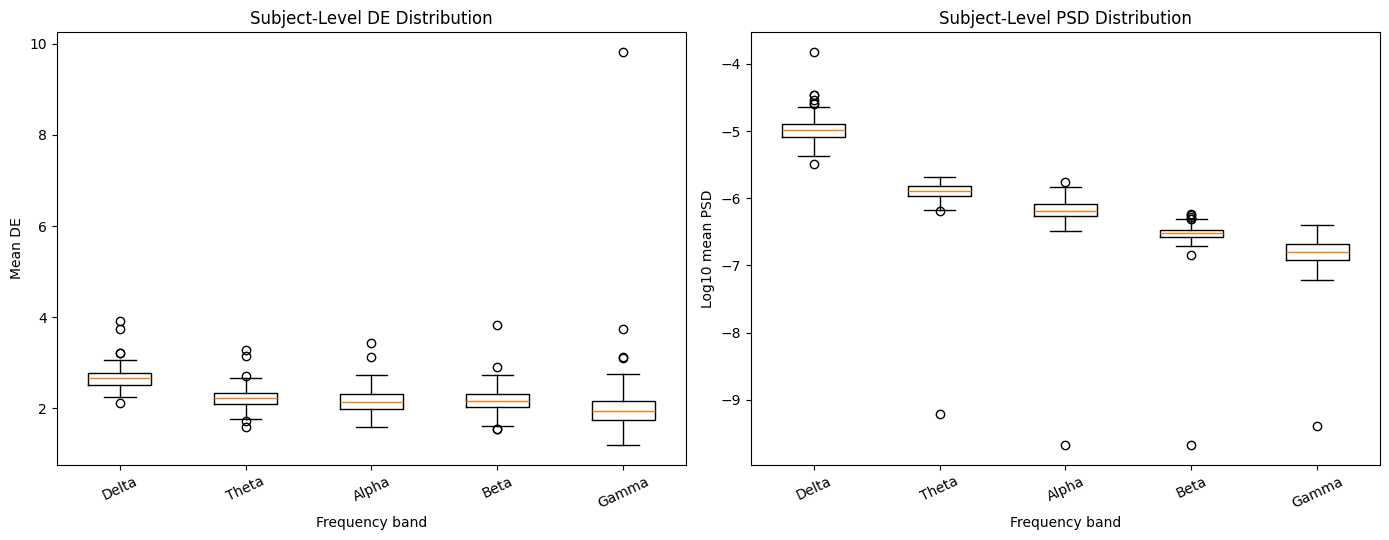

In [111]:
# Cell 43: Plot subject-level DE and log-PSD distributions

de_band_values = [
    de_subject_band_df[
        band
    ]
    .dropna()
    .values
    for band in FREQUENCY_BANDS
]

log_psd_band_values = [
    np.log10(
        psd_subject_band_df[
            band
        ]
        .clip(lower=1e-20)
        .dropna()
        .values
    )
    for band in FREQUENCY_BANDS
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.5),
)

axes[0].boxplot(
    de_band_values,
    tick_labels=FREQUENCY_BANDS,
    showfliers=True,
)

axes[0].set_title(
    "Subject-Level DE Distribution"
)

axes[0].set_xlabel(
    "Frequency band"
)

axes[0].set_ylabel(
    "Mean DE"
)

axes[1].boxplot(
    log_psd_band_values,
    tick_labels=FREQUENCY_BANDS,
    showfliers=True,
)

axes[1].set_title(
    "Subject-Level PSD Distribution"
)

axes[1].set_xlabel(
    "Frequency band"
)

axes[1].set_ylabel(
    "Log10 mean PSD"
)

for axis in axes:
    axis.tick_params(
        axis="x",
        rotation=25,
    )

plt.tight_layout()
plt.show()

In [112]:
# Cell 44: Identify subject-level DE outliers using the IQR rule

outlier_records = []

for band in FREQUENCY_BANDS:
    q1 = de_subject_band_df[
        band
    ].quantile(0.25)

    q3 = de_subject_band_df[
        band
    ].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (
        (
            de_subject_band_df[band]
            < lower_bound
        )
        |
        (
            de_subject_band_df[band]
            > upper_bound
        )
    )

    for _, row in (
        de_subject_band_df.loc[
            mask,
            ["Subject", band],
        ]
        .iterrows()
    ):
        outlier_records.append({
            "Subject": row["Subject"],
            "Frequency band": band,
            "Value": row[band],
        })

de_outliers_df = pd.DataFrame(
    outlier_records
)

if de_outliers_df.empty:
    print(
        "No DE outliers detected by "
        "the 1.5×IQR rule."
    )
else:
    de_outlier_summary = (
        de_outliers_df
        .groupby("Subject")
        .agg(
            Outlier_band_count=(
                "Frequency band",
                "nunique",
            ),
            Outlier_bands=(
                "Frequency band",
                lambda values: ", ".join(
                    sorted(set(values))
                ),
            ),
        )
        .reset_index()
        .sort_values(
            [
                "Outlier_band_count",
                "Subject",
            ],
            ascending=[False, True],
        )
    )

    display(de_outlier_summary)

,Subject,Outlier_band_count,Outlier_bands
2,sub023,5,"Alpha, Beta, Delta, Gamma, Theta"
3,sub030,5,"Alpha, Beta, Delta, Gamma, Theta"
7,sub102,3,"Beta, Delta, Theta"
0,sub003,2,"Delta, Gamma"
1,sub010,1,Gamma
4,sub052,1,Theta
5,sub057,1,Beta
6,sub091,1,Delta
8,sub106,1,Theta


In [113]:
# Cell 45: Build subject-emotion DE profiles using validated dataset metadata

video_mapping = (
    video_emotion_df[
        [
            "Video index",
            "Emotion",
        ]
    ]
    .sort_values(
        "Video index"
    )
    .copy()
)

assert len(
    video_mapping
) == ACTUAL_VIDEOS

assert video_mapping[
    "Video index"
].tolist() == list(
    range(
        1,
        ACTUAL_VIDEOS + 1,
    )
)

video_labels = (
    video_mapping[
        "Emotion"
    ]
    .tolist()
)

emotion_de_records = []

for path in de_files:
    array = load_pickle_array(
        path
    )

    if array.shape[0] != len(
        video_mapping
    ):
        raise ValueError(
            f"DE video count in {path.name} is {array.shape[0]}, "
            f"but metadata contains {len(video_mapping)} videos."
        )

    if array.shape[-1] != len(
        FREQUENCY_BANDS
    ):
        raise ValueError(
            f"Unexpected number of DE bands in {path.name}: "
            f"{array.shape[-1]}"
        )

    subject = subject_id_from_path(
        path
    )

    for emotion in EXPECTED_EMOTIONS:
        video_positions = (
            video_mapping.loc[
                video_mapping[
                    "Emotion"
                ] == emotion,
                "Video index",
            ]
            .astype(int)
            .sub(1)
            .tolist()
        )

        if not video_positions:
            raise ValueError(
                f"No videos were mapped to emotion '{emotion}'."
            )

        emotion_data = array[
            video_positions,
            :,
            :,
            :,
        ]

        band_means = np.nanmean(
            emotion_data,
            axis=tuple(
                range(
                    emotion_data.ndim - 1
                )
            ),
        )

        record = {
            "Subject": subject,
            "Emotion": emotion,
            "Videos averaged": len(
                video_positions
            ),
        }

        for band_name, value in zip(
            FREQUENCY_BANDS,
            band_means,
        ):
            record[
                band_name
            ] = float(value)

        emotion_de_records.append(
            record
        )

de_emotion_band_df = pd.DataFrame(
    emotion_de_records
)

expected_emotion_rows = (
    len(de_files)
    * len(EXPECTED_EMOTIONS)
)

assert len(
    de_emotion_band_df
) == expected_emotion_rows

print(
    "Subject-emotion DE rows:",
    len(de_emotion_band_df),
)

Subject-emotion DE rows: 1107


In [114]:
# Cell 46: Display emotion-by-frequency-band mean DE table

emotion_band_mean = (
    de_emotion_band_df
    .groupby("Emotion")[
        FREQUENCY_BANDS
    ]
    .mean()
    .reindex(EXPECTED_EMOTIONS)
)

display(
    emotion_band_mean.round(4)
)

,Delta,Theta,Alpha,Beta,Gamma
Emotion,,,,,
anger,2.6569,2.2216,2.1680,2.1973,1.9898
disgust,2.6704,2.2063,2.1339,2.1782,2.0682
fear,2.6910,2.2442,2.1516,2.1918,2.0471
sadness,2.7292,2.2503,2.1922,2.2086,2.0384
amusement,2.6408,2.2146,2.1622,2.1839,2.0436
inspiration,2.6607,2.2096,2.1576,2.1962,2.0225
joy,2.6673,2.2231,2.1575,2.1893,2.0407
tenderness,2.6564,2.2286,2.2025,2.2158,2.0368
neutral,2.7053,2.2395,2.1978,2.2066,2.0310


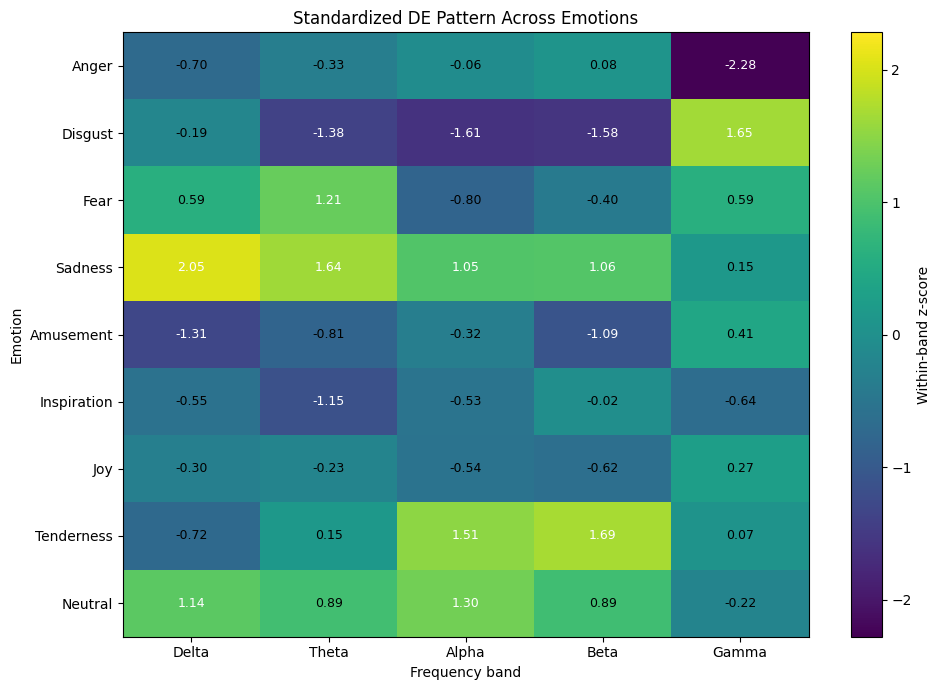

,Delta,Theta,Alpha,Beta,Gamma
Emotion,,,,,
anger,2.6569,2.2216,2.1680,2.1973,1.9898
disgust,2.6704,2.2063,2.1339,2.1782,2.0682
fear,2.6910,2.2442,2.1516,2.1918,2.0471
sadness,2.7292,2.2503,2.1922,2.2086,2.0384
amusement,2.6408,2.2146,2.1622,2.1839,2.0436
inspiration,2.6607,2.2096,2.1576,2.1962,2.0225
joy,2.6673,2.2231,2.1575,2.1893,2.0407
tenderness,2.6564,2.2286,2.2025,2.2158,2.0368
neutral,2.7053,2.2395,2.1978,2.2066,2.0310


In [115]:
# Cell 47: Plot annotated standardized emotion-by-frequency-band DE heatmap

emotion_band_mean = (
    de_emotion_band_df
    .groupby("Emotion")[FREQUENCY_BANDS]
    .mean()
    .reindex(EXPECTED_EMOTIONS)
)

# Standardize independently within each frequency band.
band_standard_deviation = (
    emotion_band_mean.std(
        axis=0,
        ddof=0,
    )
    .replace(0, np.nan)
)

emotion_band_z = (
    emotion_band_mean
    - emotion_band_mean.mean(axis=0)
) / band_standard_deviation

assert emotion_band_z.notna().all().all(), (
    "The standardized heatmap contains missing values."
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

image = ax.imshow(
    emotion_band_z.values,
    aspect="auto",
    vmin=-np.nanmax(
        np.abs(emotion_band_z.values)
    ),
    vmax=np.nanmax(
        np.abs(emotion_band_z.values)
    ),
)

ax.set_xticks(
    np.arange(
        len(FREQUENCY_BANDS)
    )
)

ax.set_xticklabels(
    FREQUENCY_BANDS
)

ax.set_yticks(
    np.arange(
        len(EXPECTED_EMOTIONS)
    )
)

ax.set_yticklabels([
    emotion.title()
    for emotion in EXPECTED_EMOTIONS
])

ax.set_xlabel(
    "Frequency band"
)

ax.set_ylabel(
    "Emotion"
)

ax.set_title(
    "Standardized DE Pattern Across Emotions"
)

# Add the actual standardized value inside every cell.
for row_index in range(
    emotion_band_z.shape[0]
):
    for column_index in range(
        emotion_band_z.shape[1]
    ):
        value = emotion_band_z.iloc[
            row_index,
            column_index,
        ]

        text_color = (
            "white"
            if abs(value) > 1
            else "black"
        )

        ax.text(
            column_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=9,
        )

fig.colorbar(
    image,
    ax=ax,
    label="Within-band z-score",
)

plt.tight_layout()
plt.show()

display(
    emotion_band_mean.round(4)
)

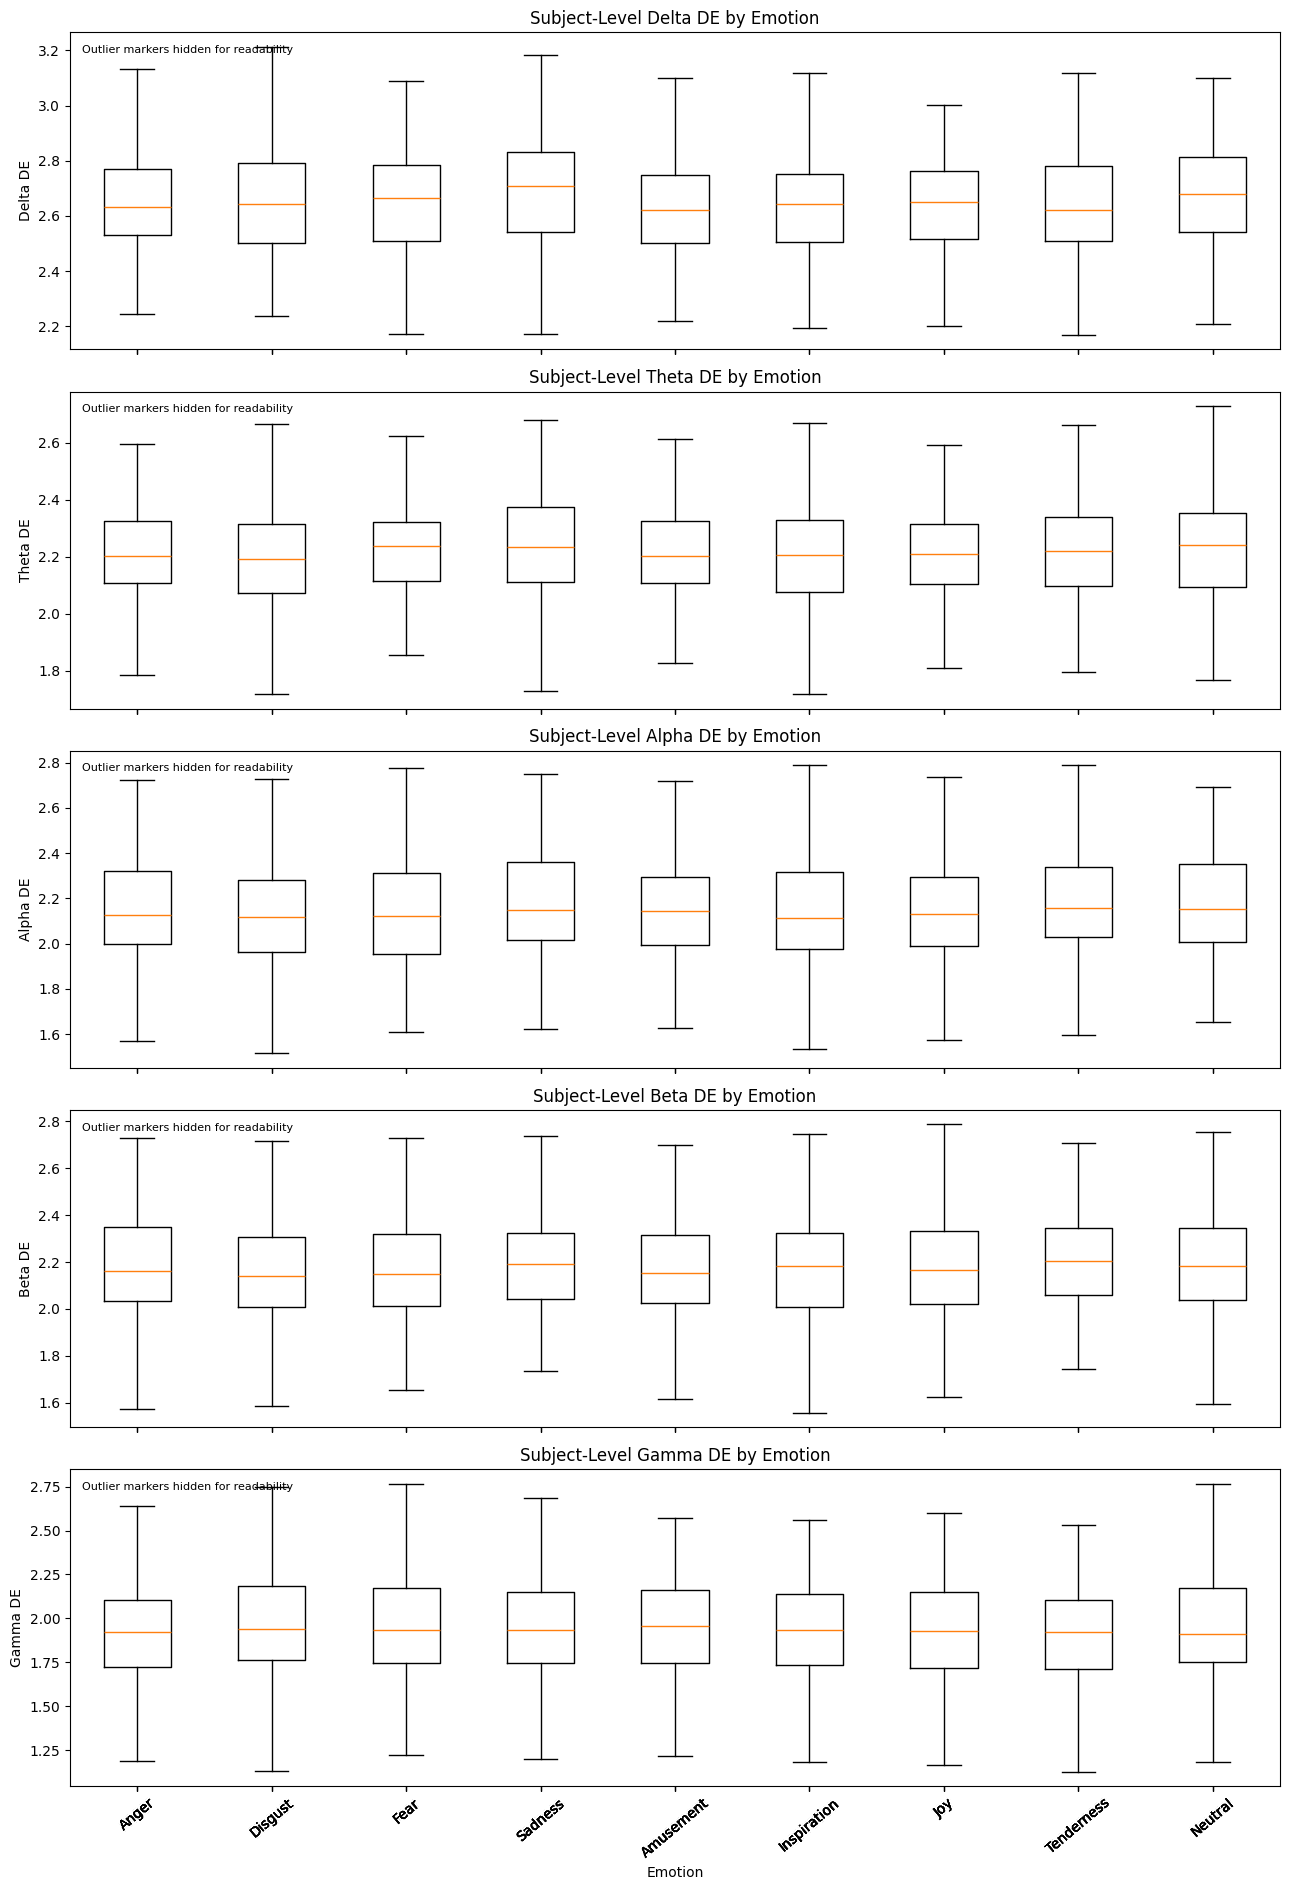

In [116]:
# Cell 48: Plot subject-level DE distributions for each emotion and band

fig, axes = plt.subplots(
    len(FREQUENCY_BANDS),
    1,
    figsize=(13, 19),
    sharex=True,
)

emotion_tick_labels = [
    emotion.title()
    for emotion in EXPECTED_EMOTIONS
]

for axis, band in zip(
    axes,
    FREQUENCY_BANDS,
):
    emotion_values = [
        de_emotion_band_df.loc[
            de_emotion_band_df[
                "Emotion"
            ] == emotion,
            band,
        ]
        .dropna()
        .values
        for emotion in EXPECTED_EMOTIONS
    ]

    axis.boxplot(
        emotion_values,
        tick_labels=emotion_tick_labels,
        showfliers=False,
    )

    axis.set_title(
        f"Subject-Level {band} DE by Emotion"
    )

    axis.set_ylabel(
        f"{band} DE"
    )

    axis.text(
        0.01,
        0.96,
        "Outlier markers hidden for readability",
        transform=axis.transAxes,
        ha="left",
        va="top",
        fontsize=8,
    )

axes[-1].tick_params(
    axis="x",
    rotation=40,
)

axes[-1].set_xlabel(
    "Emotion"
)

plt.tight_layout()
plt.show()

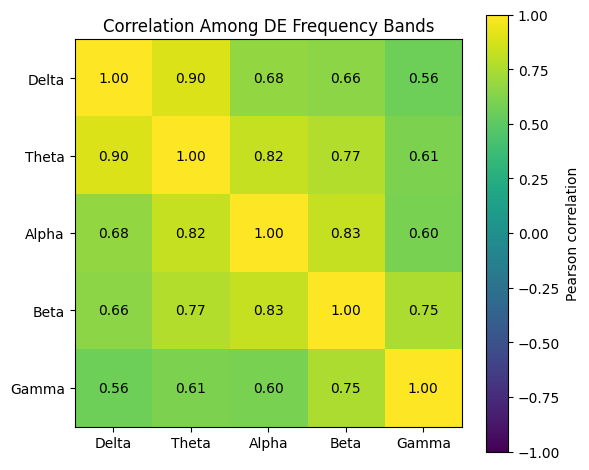

In [117]:
# Cell 49: Plot correlation among DE frequency-band features

band_correlation = (
    de_emotion_band_df[
        FREQUENCY_BANDS
    ]
    .corr()
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

image = ax.imshow(
    band_correlation.values,
    vmin=-1,
    vmax=1,
)

ax.set_xticks(
    np.arange(
        len(FREQUENCY_BANDS)
    )
)
ax.set_xticklabels(
    FREQUENCY_BANDS
)

ax.set_yticks(
    np.arange(
        len(FREQUENCY_BANDS)
    )
)
ax.set_yticklabels(
    FREQUENCY_BANDS
)

for row in range(
    len(FREQUENCY_BANDS)
):
    for column in range(
        len(FREQUENCY_BANDS)
    ):
        ax.text(
            column,
            row,
            f"{band_correlation.iloc[row, column]:.2f}",
            ha="center",
            va="center",
        )

ax.set_title(
    "Correlation Among DE Frequency Bands"
)

fig.colorbar(
    image,
    ax=ax,
    label="Pearson correlation",
)

plt.tight_layout()
plt.show()

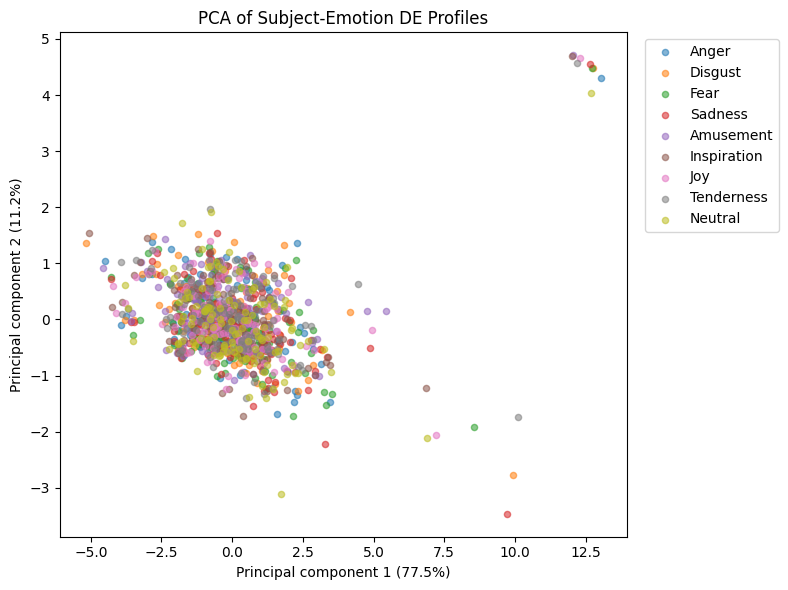

In [118]:
# Cell 50: Visualize subject-emotion DE profiles using PCA

pca_input = (
    de_emotion_band_df[
        FREQUENCY_BANDS
    ]
)

pca_scaled = StandardScaler().fit_transform(
    pca_input
)

pca_model = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)

pca_coordinates = (
    pca_model.fit_transform(
        pca_scaled
    )
)

pca_df = pd.DataFrame({
    "PC1": pca_coordinates[:, 0],
    "PC2": pca_coordinates[:, 1],
    "Emotion": de_emotion_band_df[
        "Emotion"
    ].values,
})

fig, ax = plt.subplots(
    figsize=(8, 6)
)

for emotion in EXPECTED_EMOTIONS:
    emotion_subset = pca_df[
        pca_df["Emotion"] == emotion
    ]

    ax.scatter(
        emotion_subset["PC1"],
        emotion_subset["PC2"],
        label=emotion.title(),
        alpha=0.55,
        s=20,
    )

ax.set_title(
    "PCA of Subject-Emotion DE Profiles"
)

ax.set_xlabel(
    "Principal component 1 "
    f"({pca_model.explained_variance_ratio_[0] * 100:.1f}%)"
)

ax.set_ylabel(
    "Principal component 2 "
    f"({pca_model.explained_variance_ratio_[1] * 100:.1f}%)"
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

In [119]:
# Cell 51: Attach emotion labels to processed EEG signal-feature records

signal_features_labeled = (
    signal_features_df
    .merge(
        video_emotion_df[
            [
                "Video index",
                "Emotion",
                "Valence",
            ]
        ],
        on="Video index",
        how="left",
        validate="many_to_one",
    )
)

expected_labeled_rows = len(
    signal_features_df
)

assert len(
    signal_features_labeled
) == expected_labeled_rows, (
    "Emotion merge changed the number of "
    "processed signal-feature rows."
)

missing_emotion_rows = int(
    signal_features_labeled[
        "Emotion"
    ].isna().sum()
)

missing_valence_rows = int(
    signal_features_labeled[
        "Valence"
    ].isna().sum()
)

unexpected_emotions = sorted(
    set(
        signal_features_labeled[
            "Emotion"
        ].dropna().unique()
    )
    - set(EXPECTED_EMOTIONS)
)

emotion_merge_summary = pd.DataFrame({
    "Metric": [
        "Original signal-feature rows",
        "Rows after emotion merge",
        "Rows with emotion labels",
        "Rows missing emotion labels",
        "Rows with valence labels",
        "Rows missing valence labels",
        "Unique emotion classes",
        "Expected emotion classes",
        "Unexpected emotion labels",
    ],
    "Value": [
        len(signal_features_df),
        len(signal_features_labeled),
        int(
            signal_features_labeled[
                "Emotion"
            ].notna().sum()
        ),
        missing_emotion_rows,
        int(
            signal_features_labeled[
                "Valence"
            ].notna().sum()
        ),
        missing_valence_rows,
        int(
            signal_features_labeled[
                "Emotion"
            ].nunique()
        ),
        len(EXPECTED_EMOTIONS),
        (
            ", ".join(
                unexpected_emotions
            )
            if unexpected_emotions
            else "None"
        ),
    ],
})

display(
    emotion_merge_summary
)

emotion_record_counts = (
    signal_features_labeled[
        "Emotion"
    ]
    .value_counts()
    .reindex(
        EXPECTED_EMOTIONS
    )
    .rename_axis(
        "Emotion"
    )
    .reset_index(
        name="Signal-feature records"
    )
)

display(
    emotion_record_counts
)

assert missing_emotion_rows == 0, (
    "Some processed EEG signal-feature rows "
    "could not be matched to an emotion."
)

assert missing_valence_rows == 0, (
    "Some processed EEG signal-feature rows "
    "could not be matched to a valence."
)

assert not unexpected_emotions, (
    f"Unexpected emotion labels were found: "
    f"{unexpected_emotions}"
)

assert set(
    signal_features_labeled[
        "Emotion"
    ].unique()
) == set(
    EXPECTED_EMOTIONS
), (
    "The merged signal-feature table does not contain "
    "the expected set of emotion classes."
)

,Metric,Value
0,Original signal-feature rows,110208
1,Rows after emotion merge,110208
2,Rows with emotion labels,110208
3,Rows missing emotion labels,0
4,Rows with valence labels,110208
5,Rows missing valence labels,0
6,Unique emotion classes,9
7,Expected emotion classes,9
8,Unexpected emotion labels,None


,Emotion,Signal-feature records
0,anger,11808
1,disgust,11808
2,fear,11808
3,sadness,11808
4,amusement,11808
5,inspiration,11808
6,joy,11808
7,tenderness,11808
8,neutral,15744


In [120]:
# Cell 52: Aggregate Hjorth features by subject and emotion

hjorth_subject_emotion_df = (
    signal_features_labeled
    .groupby([
        "Subject",
        "Emotion",
    ])[
        [
            "Hjorth activity",
            "Hjorth mobility",
            "Hjorth complexity",
        ]
    ]
    .mean()
    .reset_index()
)

expected_hjorth_rows = (
    EXPECTED_SUBJECTS
    * len(EXPECTED_EMOTIONS)
)

assert len(hjorth_subject_emotion_df) == expected_hjorth_rows, (
    f"Expected {expected_hjorth_rows} subject-emotion rows, "
    f"found {len(hjorth_subject_emotion_df)}."
)

print(
    "Subject-emotion Hjorth rows:",
    len(hjorth_subject_emotion_df),
)

Subject-emotion Hjorth rows: 1107


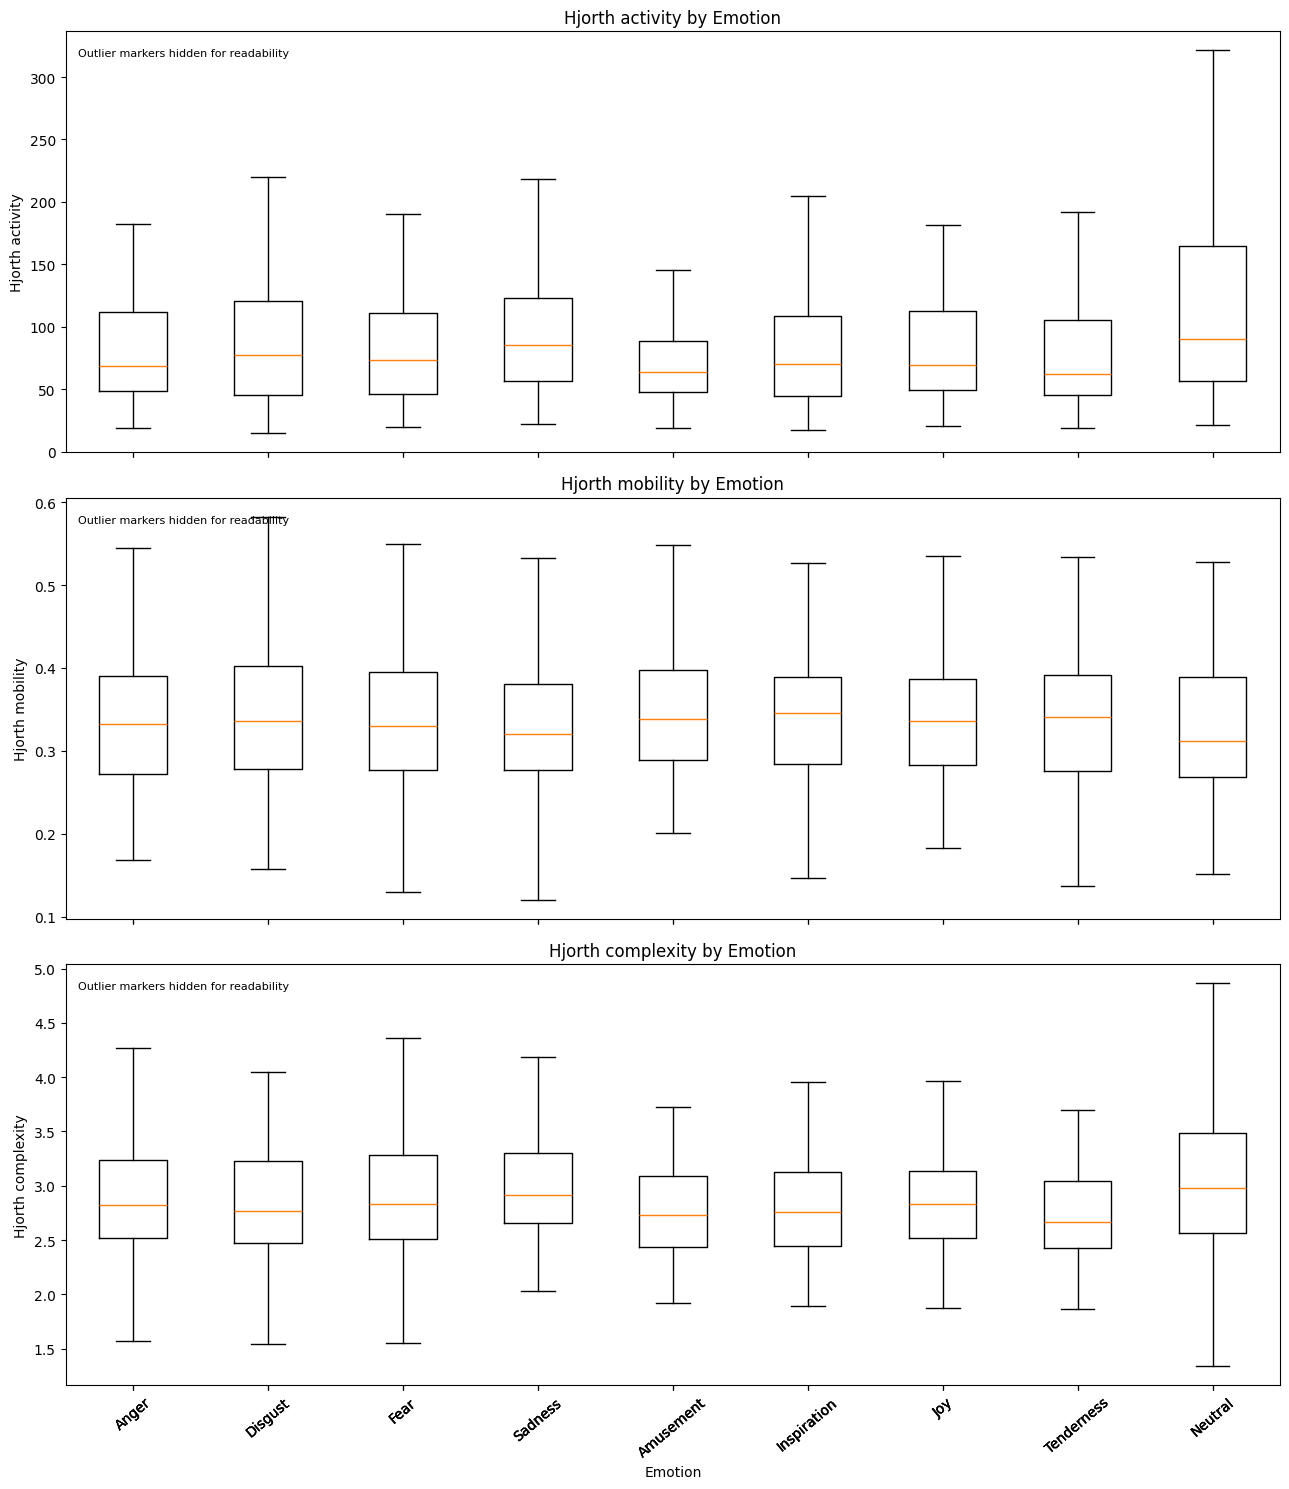

In [121]:
# Cell 53: Plot Hjorth feature distributions by emotion

hjorth_features = [
    "Hjorth activity",
    "Hjorth mobility",
    "Hjorth complexity",
]

emotion_tick_labels = [
    emotion.title()
    for emotion in EXPECTED_EMOTIONS
]

fig, axes = plt.subplots(
    len(hjorth_features),
    1,
    figsize=(13, 15),
    sharex=True,
)

for axis, feature in zip(
    axes,
    hjorth_features,
):
    emotion_values = [
        hjorth_subject_emotion_df.loc[
            hjorth_subject_emotion_df[
                "Emotion"
            ] == emotion,
            feature,
        ]
        .dropna()
        .values
        for emotion in EXPECTED_EMOTIONS
    ]

    axis.boxplot(
        emotion_values,
        tick_labels=emotion_tick_labels,
        showfliers=False,
    )

    axis.set_title(
        f"{feature} by Emotion"
    )

    axis.set_ylabel(
        feature
    )

    axis.text(
        0.01,
        0.96,
        "Outlier markers hidden for readability",
        transform=axis.transAxes,
        ha="left",
        va="top",
        fontsize=8,
    )

axes[-1].tick_params(
    axis="x",
    rotation=40,
)

axes[-1].set_xlabel(
    "Emotion"
)

plt.tight_layout()
plt.show()

In [122]:
# Cell 54: Display cohort channel orders without inferring renaming

required_order_columns = {
    "Channel number",
    "First cohort label",
    "Final processed label",
    "Position-wise label differs",
}

missing_order_columns = (
    required_order_columns
    - set(electrode_order_df.columns)
)

if missing_order_columns:
    raise KeyError(
        "electrode_order_df is missing columns: "
        f"{sorted(missing_order_columns)}"
    )


cohort_channel_order_table = (
    electrode_order_df[
        [
            "Channel number",
            "First cohort label",
            "Final processed label",
            "Position-wise label differs",
        ]
    ]
    .copy()
)


cohort_channel_order_table[
    "Interpretation"
] = np.where(
    cohort_channel_order_table[
        "Position-wise label differs"
    ],
    (
        "Different labels occupy this ordinal position; "
        "this does not prove electrode renaming."
    ),
    "Same label occupies this ordinal position.",
)


display(cohort_channel_order_table)

,Channel number,First cohort label,Final processed label,Position-wise label differs,Interpretation
0,1,Fp1,Fp1,False,Same label occupies this ordinal position.
1,2,Fp2,Fp2,False,Same label occupies this ordinal position.
2,3,Fz,Fz,False,Same label occupies this ordinal position.
3,4,F3,F3,False,Same label occupies this ordinal position.
4,5,F4,F4,False,Same label occupies this ordinal position.
5,6,F7,F7,False,Same label occupies this ordinal position.
6,7,F8,F8,False,Same label occupies this ordinal position.
7,8,FC1,FC1,False,Same label occupies this ordinal position.
8,9,FC2,FC2,False,Same label occupies this ordinal position.
9,10,FC5,FC5,False,Same label occupies this ordinal position.


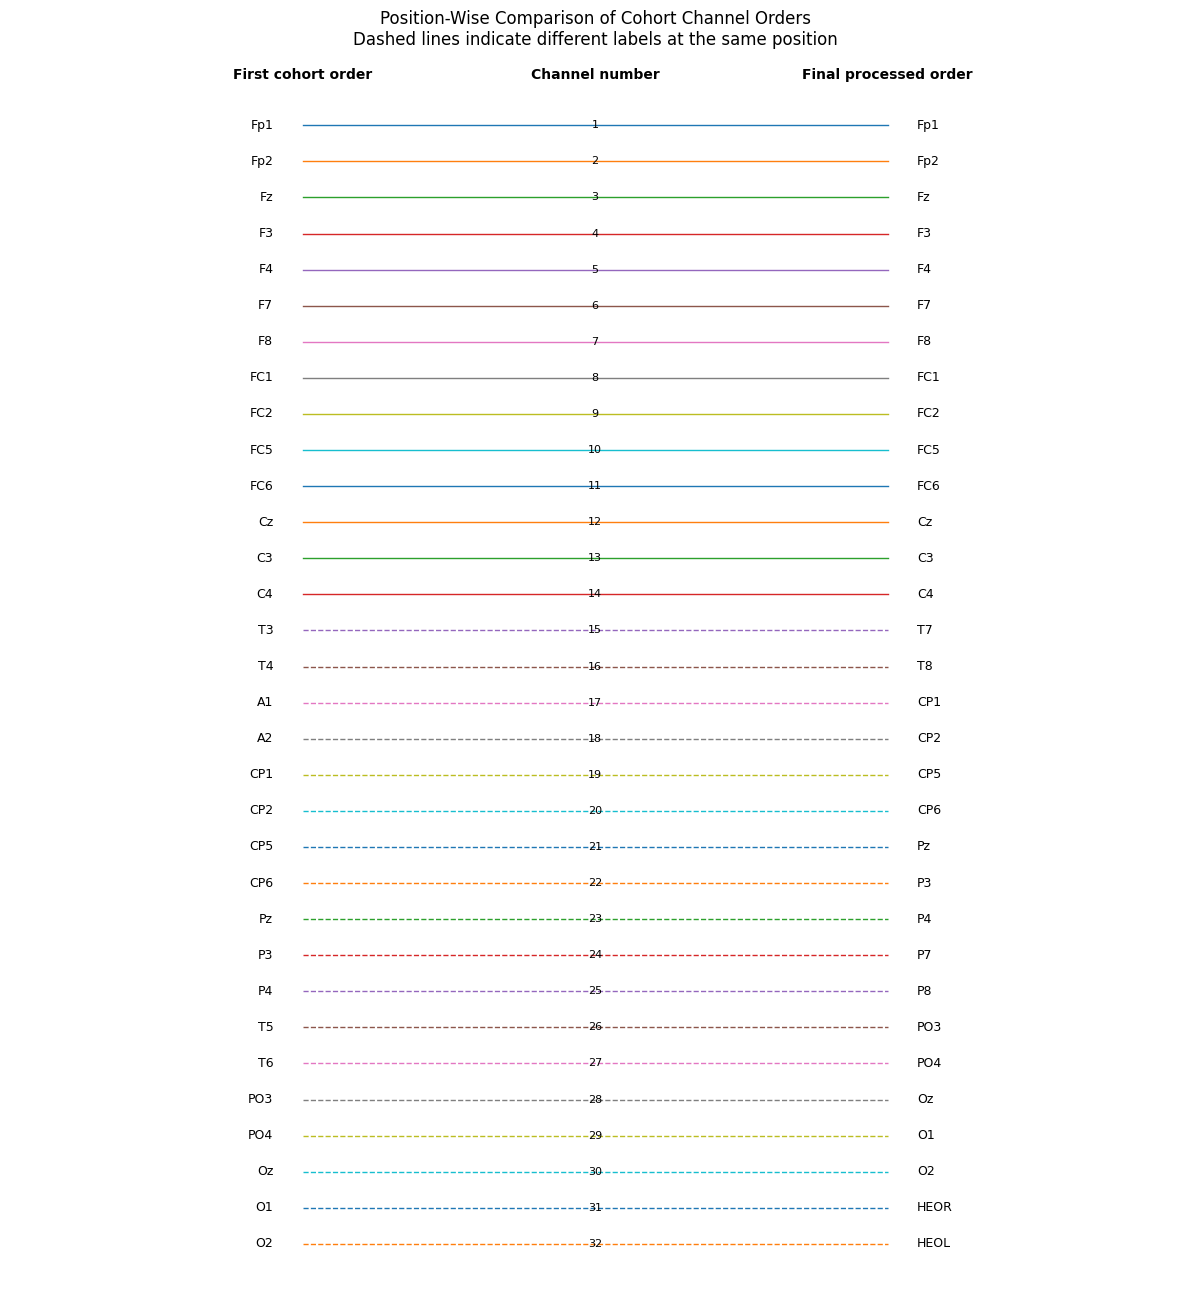

In [123]:
# Cell 55: Visualize cohort channel orders by ordinal position

position_comparison = (
    cohort_channel_order_table
    .sort_values("Channel number")
    .reset_index(drop=True)
    .copy()
)


fig, ax = plt.subplots(
    figsize=(12, 13)
)

y_positions = np.arange(
    len(position_comparison)
)[::-1]


for row_number, row in (
    position_comparison.iterrows()
):
    y_position = (
        y_positions[row_number]
    )

    labels_match = not bool(
        row[
            "Position-wise label differs"
        ]
    )

    line_style = (
        "-"
        if labels_match
        else "--"
    )

    ax.plot(
        [0, 1],
        [y_position, y_position],
        linestyle=line_style,
        linewidth=1,
    )

    ax.text(
        -0.05,
        y_position,
        row["First cohort label"],
        ha="right",
        va="center",
        fontsize=9,
    )

    ax.text(
        1.05,
        y_position,
        row["Final processed label"],
        ha="left",
        va="center",
        fontsize=9,
    )

    ax.text(
        0.5,
        y_position,
        str(
            int(
                row["Channel number"]
            )
        ),
        ha="center",
        va="center",
        fontsize=8,
    )


ax.text(
    0,
    len(position_comparison) + 0.2,
    "First cohort order",
    ha="center",
    va="bottom",
    fontweight="bold",
)

ax.text(
    1,
    len(position_comparison) + 0.2,
    "Final processed order",
    ha="center",
    va="bottom",
    fontweight="bold",
)

ax.text(
    0.5,
    len(position_comparison) + 0.2,
    "Channel number",
    ha="center",
    va="bottom",
    fontweight="bold",
)


ax.set_title(
    "Position-Wise Comparison of Cohort Channel Orders\n"
    "Dashed lines indicate different labels at the same position"
)

ax.set_xlim(-0.5, 1.5)

ax.set_ylim(
    -1,
    len(position_comparison) + 1,
)

ax.axis("off")

plt.tight_layout()
plt.show()

In [124]:
# Cell 56: Summarize cohort channel-order differences

same_position_count = int(
    (
        ~cohort_channel_order_table[
            "Position-wise label differs"
        ]
    ).sum()
)

different_position_count = int(
    cohort_channel_order_table[
        "Position-wise label differs"
    ].sum()
)


channel_order_summary = pd.DataFrame({
    "Metric": [
        "First-cohort channels",
        "Final processed channels",
        "Same label at the same ordinal position",
        "Different label at the same ordinal position",
        "Scalp EEG channels in final order",
        "Ocular/EOG channels in final order",
        "Interpretation limitation",
    ],
    "Value": [
        len(first_cohort_electrodes),
        len(electrode_names),
        same_position_count,
        different_position_count,
        len(scalp_channel_indices),
        len(ocular_channel_indices),
        (
            "Position-wise differences indicate different channel "
            "orders; they do not independently prove renaming."
        ),
    ],
})

display(channel_order_summary)


print(
    "Positions containing different labels"
)

display(
    cohort_channel_order_table.loc[
        cohort_channel_order_table[
            "Position-wise label differs"
        ],
        [
            "Channel number",
            "First cohort label",
            "Final processed label",
        ],
    ]
)

,Metric,Value
0,First-cohort channels,32
1,Final processed channels,32
2,Same label at the same ordinal position,14
3,Different label at the same ordinal position,18
4,Scalp EEG channels in final order,30
5,Ocular/EOG channels in final order,2
6,Interpretation limitation,Position-wise differences indicate different c...


Positions containing different labels


,Channel number,First cohort label,Final processed label
14,15,T3,T7
15,16,T4,T8
16,17,A1,CP1
17,18,A2,CP2
18,19,CP1,CP5
19,20,CP2,CP6
20,21,CP5,Pz
21,22,CP6,P3
22,23,Pz,P4
23,24,P3,P7


In [125]:
# Cell 57: Merge subject-level DE features with participant recording metadata

metadata_columns_for_merge = [
    "Subject",
    "Gender",
    "Age",
    "Cohort",
    "Original sampling rate",
    "Unit",
]

available_metadata_columns = [
    column
    for column in metadata_columns_for_merge
    if column in recording_clean.columns
]

required_metadata_columns = [
    "Subject",
    "Cohort",
    "Original sampling rate",
]

missing_required_columns = [
    column
    for column in required_metadata_columns
    if column not in available_metadata_columns
]

if missing_required_columns:
    raise KeyError(
        "Required recording-metadata columns are missing: "
        f"{missing_required_columns}"
    )

recording_metadata_for_merge = (
    recording_clean[
        available_metadata_columns
    ]
    .drop_duplicates(
        subset="Subject",
        keep="first",
    )
    .copy()
)

de_with_metadata = (
    de_subject_band_df
    .merge(
        recording_metadata_for_merge,
        on="Subject",
        how="left",
        validate="one_to_one",
    )
)

assert len(
    de_with_metadata
) == len(
    de_subject_band_df
), (
    "Participant-metadata merge changed the number "
    "of subject-level DE rows."
)

missing_recording_metadata = (
    de_with_metadata[
        required_metadata_columns[1:]
    ]
    .isna()
    .any(axis=1)
)

missing_subjects = (
    de_with_metadata.loc[
        missing_recording_metadata,
        "Subject",
    ]
    .tolist()
)

sampling_rate_counts = (
    de_with_metadata[
        "Original sampling rate"
    ]
    .value_counts(
        dropna=False
    )
    .sort_index()
)

cohort_counts = (
    de_with_metadata[
        "Cohort"
    ]
    .value_counts(
        dropna=False
    )
)

metadata_merge_summary = pd.DataFrame({
    "Metric": [
        "Subject-level DE rows",
        "Rows after metadata merge",
        "Subjects matched to cohort",
        "Subjects missing cohort",
        "Subjects matched to sampling rate",
        "Subjects missing sampling rate",
        "Unique sampling-rate groups",
        "Unique cohort groups",
    ],
    "Value": [
        len(de_subject_band_df),
        len(de_with_metadata),
        int(
            de_with_metadata[
                "Cohort"
            ].notna().sum()
        ),
        int(
            de_with_metadata[
                "Cohort"
            ].isna().sum()
        ),
        int(
            de_with_metadata[
                "Original sampling rate"
            ].notna().sum()
        ),
        int(
            de_with_metadata[
                "Original sampling rate"
            ].isna().sum()
        ),
        int(
            de_with_metadata[
                "Original sampling rate"
            ].nunique()
        ),
        int(
            de_with_metadata[
                "Cohort"
            ].nunique()
        ),
    ],
})

display(
    metadata_merge_summary
)

print(
    "Subjects by original sampling rate"
)

display(
    sampling_rate_counts
    .rename(
        "Subjects"
    )
    .reset_index()
    .rename(
        columns={
            "Original sampling rate":
                "Original sampling rate",
        }
    )
)

print(
    "Subjects by cohort"
)

display(
    cohort_counts
    .rename(
        "Subjects"
    )
    .reset_index()
    .rename(
        columns={
            "Cohort": "Cohort",
        }
    )
)

if missing_subjects:
    print(
        "Subjects missing required recording metadata:",
        missing_subjects,
    )

assert not missing_subjects, (
    "Some subject-level DE records could not be matched "
    "to the required recording metadata."
)

,Metric,Value
0,Subject-level DE rows,123
1,Rows after metadata merge,123
2,Subjects matched to cohort,123
3,Subjects missing cohort,0
4,Subjects matched to sampling rate,123
5,Subjects missing sampling rate,0
6,Unique sampling-rate groups,2
7,Unique cohort groups,2


Subjects by original sampling rate


,Original sampling rate,Subjects
0,250,55
1,1000,68


Subjects by cohort


,Cohort,Subjects
0,2,62
1,1,61


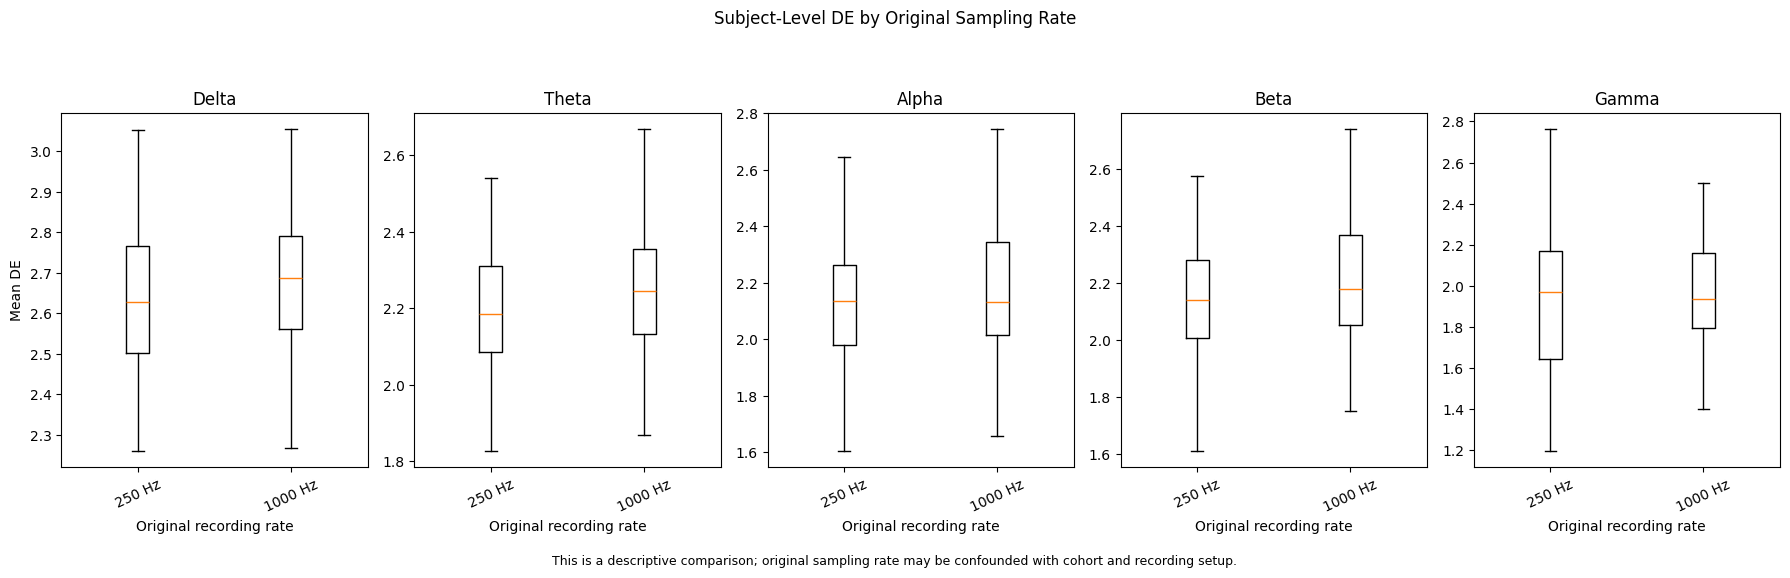

In [126]:
# Cell 58: Compare subject-level DE by original sampling-rate group

sampling_rate_groups = sorted(
    de_with_metadata[
        "Original sampling rate"
    ]
    .dropna()
    .unique()
)

if len(sampling_rate_groups) < 2:
    raise ValueError(
        "At least two original sampling-rate groups are required "
        "for this comparison."
    )

fig, axes = plt.subplots(
    1,
    len(FREQUENCY_BANDS),
    figsize=(18, 5.5),
    sharey=False,
)

sampling_rate_tick_labels = [
    f"{int(rate)} Hz"
    for rate in sampling_rate_groups
]

for axis_index, (
    axis,
    band,
) in enumerate(
    zip(
        axes,
        FREQUENCY_BANDS,
    )
):
    group_values = [
        de_with_metadata.loc[
            de_with_metadata[
                "Original sampling rate"
            ] == sampling_rate,
            band,
        ]
        .dropna()
        .values
        for sampling_rate
        in sampling_rate_groups
    ]

    axis.boxplot(
        group_values,
        tick_labels=sampling_rate_tick_labels,
        showfliers=False,
    )

    axis.set_title(
        band
    )

    axis.set_xlabel(
        "Original recording rate"
    )

    if axis_index == 0:
        axis.set_ylabel(
            "Mean DE"
        )

    axis.tick_params(
        axis="x",
        rotation=25,
    )

fig.suptitle(
    "Subject-Level DE by Original Sampling Rate",
    y=1.02,
)

fig.text(
    0.5,
    0.01,
    "This is a descriptive comparison; original sampling rate may be "
    "confounded with cohort and recording setup.",
    ha="center",
    fontsize=9,
)

plt.tight_layout(
    rect=[
        0,
        0.04,
        1,
        0.96,
    ]
)

plt.show()

In [127]:
# Cell 59: Build subject-emotion-window DE profiles from dataset feature windows

# FACED DE and PSD files use non-overlapping one-second windows.
# Therefore the third DE dimension is labelled as Second.

secondwise_records = []

for path in de_files:
    de_array = load_pickle_array(
        path
    )

    if de_array.ndim != 4:
        raise ValueError(
            f"DE array in {path.name} must be 4D, "
            f"but found {de_array.shape}."
        )

    number_of_videos = (
        de_array.shape[0]
    )

    number_of_windows = (
        de_array.shape[2]
    )

    number_of_bands = (
        de_array.shape[3]
    )

    if number_of_videos != len(
        video_mapping
    ):
        raise ValueError(
            f"DE video count in {path.name} is {number_of_videos}, "
            f"but metadata contains {len(video_mapping)}."
        )

    if number_of_bands != len(
        FREQUENCY_BANDS
    ):
        raise ValueError(
            f"DE band count in {path.name} is {number_of_bands}, "
            f"but {len(FREQUENCY_BANDS)} band labels are defined."
        )

    subject = subject_id_from_path(
        path
    )

    for emotion in EXPECTED_EMOTIONS:
        video_positions = (
            video_mapping.loc[
                video_mapping[
                    "Emotion"
                ] == emotion,
                "Video index",
            ]
            .astype(int)
            .sub(1)
            .tolist()
        )

        emotion_data = de_array[
            video_positions,
            :,
            :,
            :,
        ]

        # Average across videos and electrodes only.
        # Preserve all dataset-provided one-second windows.
        window_band_means = np.nanmean(
            emotion_data,
            axis=(0, 1),
        )

        expected_window_shape = (
            number_of_windows,
            number_of_bands,
        )

        if (
            window_band_means.shape
            != expected_window_shape
        ):
            raise ValueError(
                f"Unexpected temporal feature shape for "
                f"{subject}, {emotion}: "
                f"{window_band_means.shape}"
            )

        for window_index in range(
            number_of_windows
        ):
            record = {
                "Subject": subject,
                "Emotion": emotion,
                "Second": window_index + 1,
            }

            for band_index, band_name in enumerate(
                FREQUENCY_BANDS
            ):
                record[
                    band_name
                ] = float(
                    window_band_means[
                        window_index,
                        band_index,
                    ]
                )

            secondwise_records.append(
                record
            )

secondwise_de_df = pd.DataFrame(
    secondwise_records
)

expected_secondwise_rows = (
    len(de_files)
    * len(EXPECTED_EMOTIONS)
    * ACTUAL_DE_WINDOWS
)

assert len(
    secondwise_de_df
) == expected_secondwise_rows, (
    f"Expected {expected_secondwise_rows} second-wise rows, "
    f"found {len(secondwise_de_df)}."
)

assert secondwise_de_df[
    "Second"
].min() == 1

assert secondwise_de_df[
    "Second"
].max() == ACTUAL_DE_WINDOWS

print(
    "Second-wise DE rows:",
    len(secondwise_de_df),
)

display(
    secondwise_de_df.head()
)

Second-wise DE rows: 33210


,Subject,Emotion,Second,Delta,Theta,Alpha,Beta,Gamma
0,sub000,anger,1,2.845908,2.349579,2.078439,2.359552,2.106003
1,sub000,anger,2,2.582911,2.295847,2.012376,2.294490,2.126530
2,sub000,anger,3,2.750915,2.369576,2.063476,2.260733,2.162410
3,sub000,anger,4,2.752643,2.403490,2.142371,2.353228,2.191648
4,sub000,anger,5,2.518337,2.174057,1.946549,2.277276,2.155124


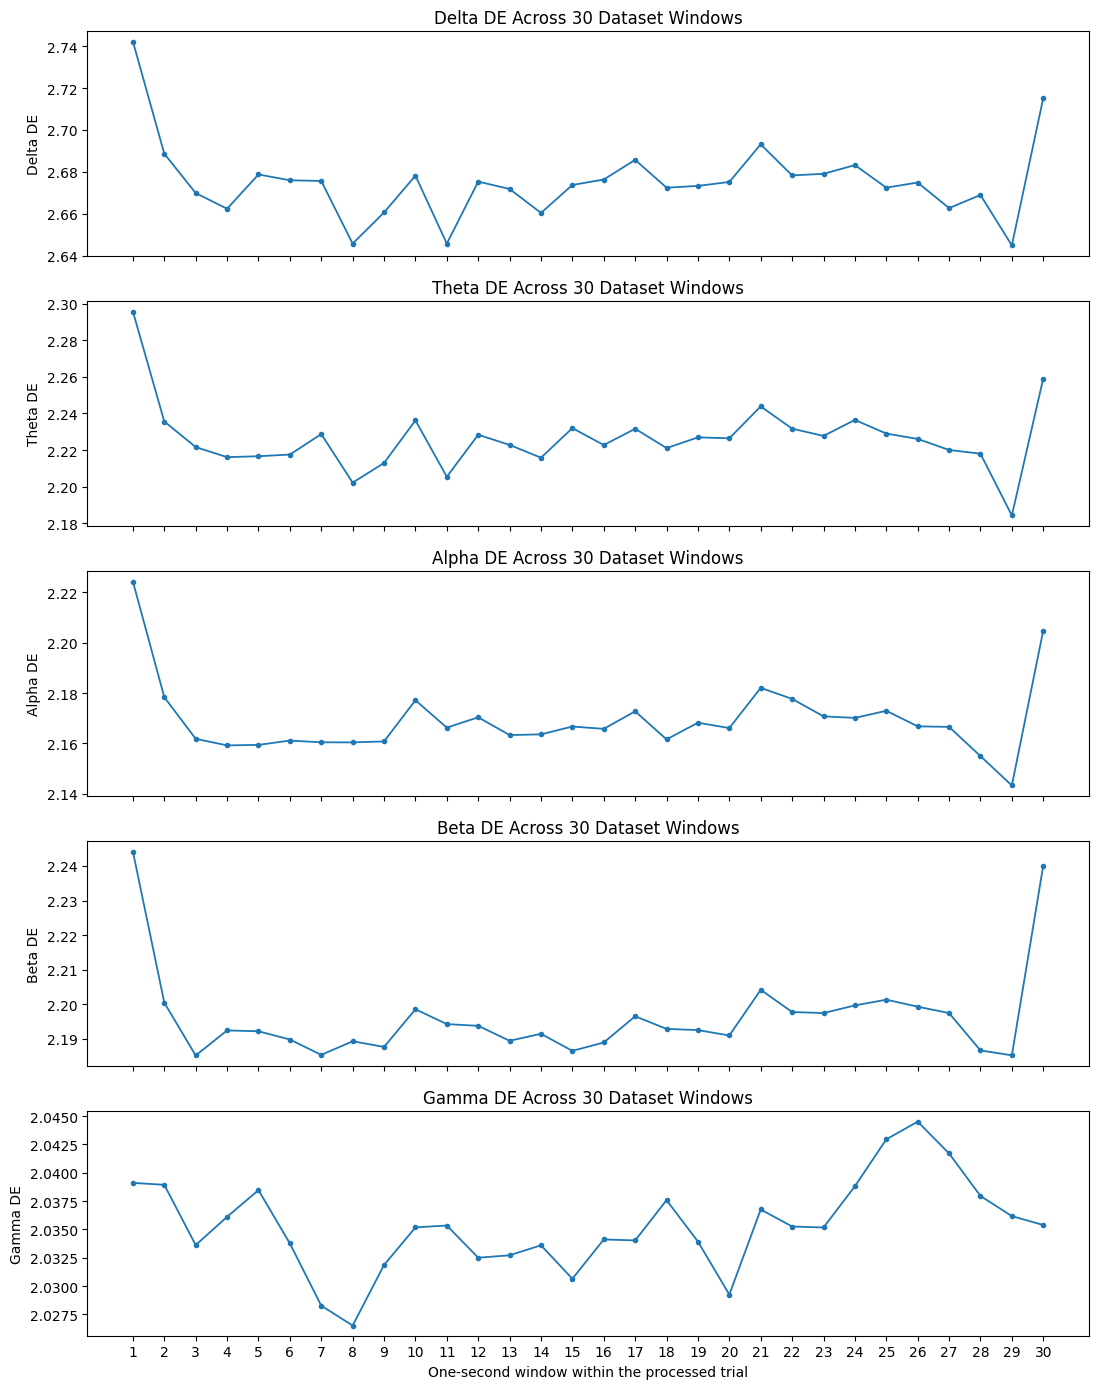

,Second,Delta,Theta,Alpha,Beta,Gamma
0,1,2.7423,2.2958,2.2242,2.2442,2.0391
1,2,2.6887,2.2356,2.1784,2.2005,2.0389
2,3,2.6698,2.2216,2.1618,2.1852,2.0336
3,4,2.6623,2.2161,2.1592,2.1925,2.0361
4,5,2.6787,2.2166,2.1594,2.1922,2.0385
5,6,2.6760,2.2175,2.1612,2.1898,2.0338
6,7,2.6756,2.2287,2.1605,2.1854,2.0283
7,8,2.6457,2.2021,2.1604,2.1893,2.0265
8,9,2.6606,2.2129,2.1608,2.1877,2.0319
9,10,2.6782,2.2362,2.1771,2.1986,2.0352


In [128]:
# Cell 60: Plot dataset-wide DE trajectories across all available windows

overall_windowwise_de = (
    secondwise_de_df
    .groupby("Second")[FREQUENCY_BANDS]
    .mean()
    .reset_index()
    .sort_values("Second")
)

actual_temporal_windows = sorted(
    secondwise_de_df[
        "Second"
    ].unique()
)

assert len(actual_temporal_windows) == ACTUAL_DE_WINDOWS, (
    f"Expected {ACTUAL_DE_WINDOWS} DE windows, "
    f"found {len(actual_temporal_windows)}."
)

assert actual_temporal_windows == list(
    range(
        1,
        ACTUAL_DE_WINDOWS + 1,
    )
), "Temporal-window indices are not consecutive."

fig, axes = plt.subplots(
    len(FREQUENCY_BANDS),
    1,
    figsize=(11, 14),
    sharex=True,
)

for axis, band in zip(
    axes,
    FREQUENCY_BANDS,
):
    axis.plot(
        overall_windowwise_de["Second"],
        overall_windowwise_de[band],
        marker="o",
        markersize=3,
        linewidth=1.3,
    )

    axis.set_title(
        f"{band} DE Across "
        f"{ACTUAL_DE_WINDOWS} Dataset Windows"
    )

    axis.set_ylabel(
        f"{band} DE"
    )

axes[-1].set_xlabel(
    "One-second window within the processed trial"
)

axes[-1].set_xticks(
    actual_temporal_windows
)

plt.tight_layout()
plt.show()

display(
    overall_windowwise_de.round(4)
)

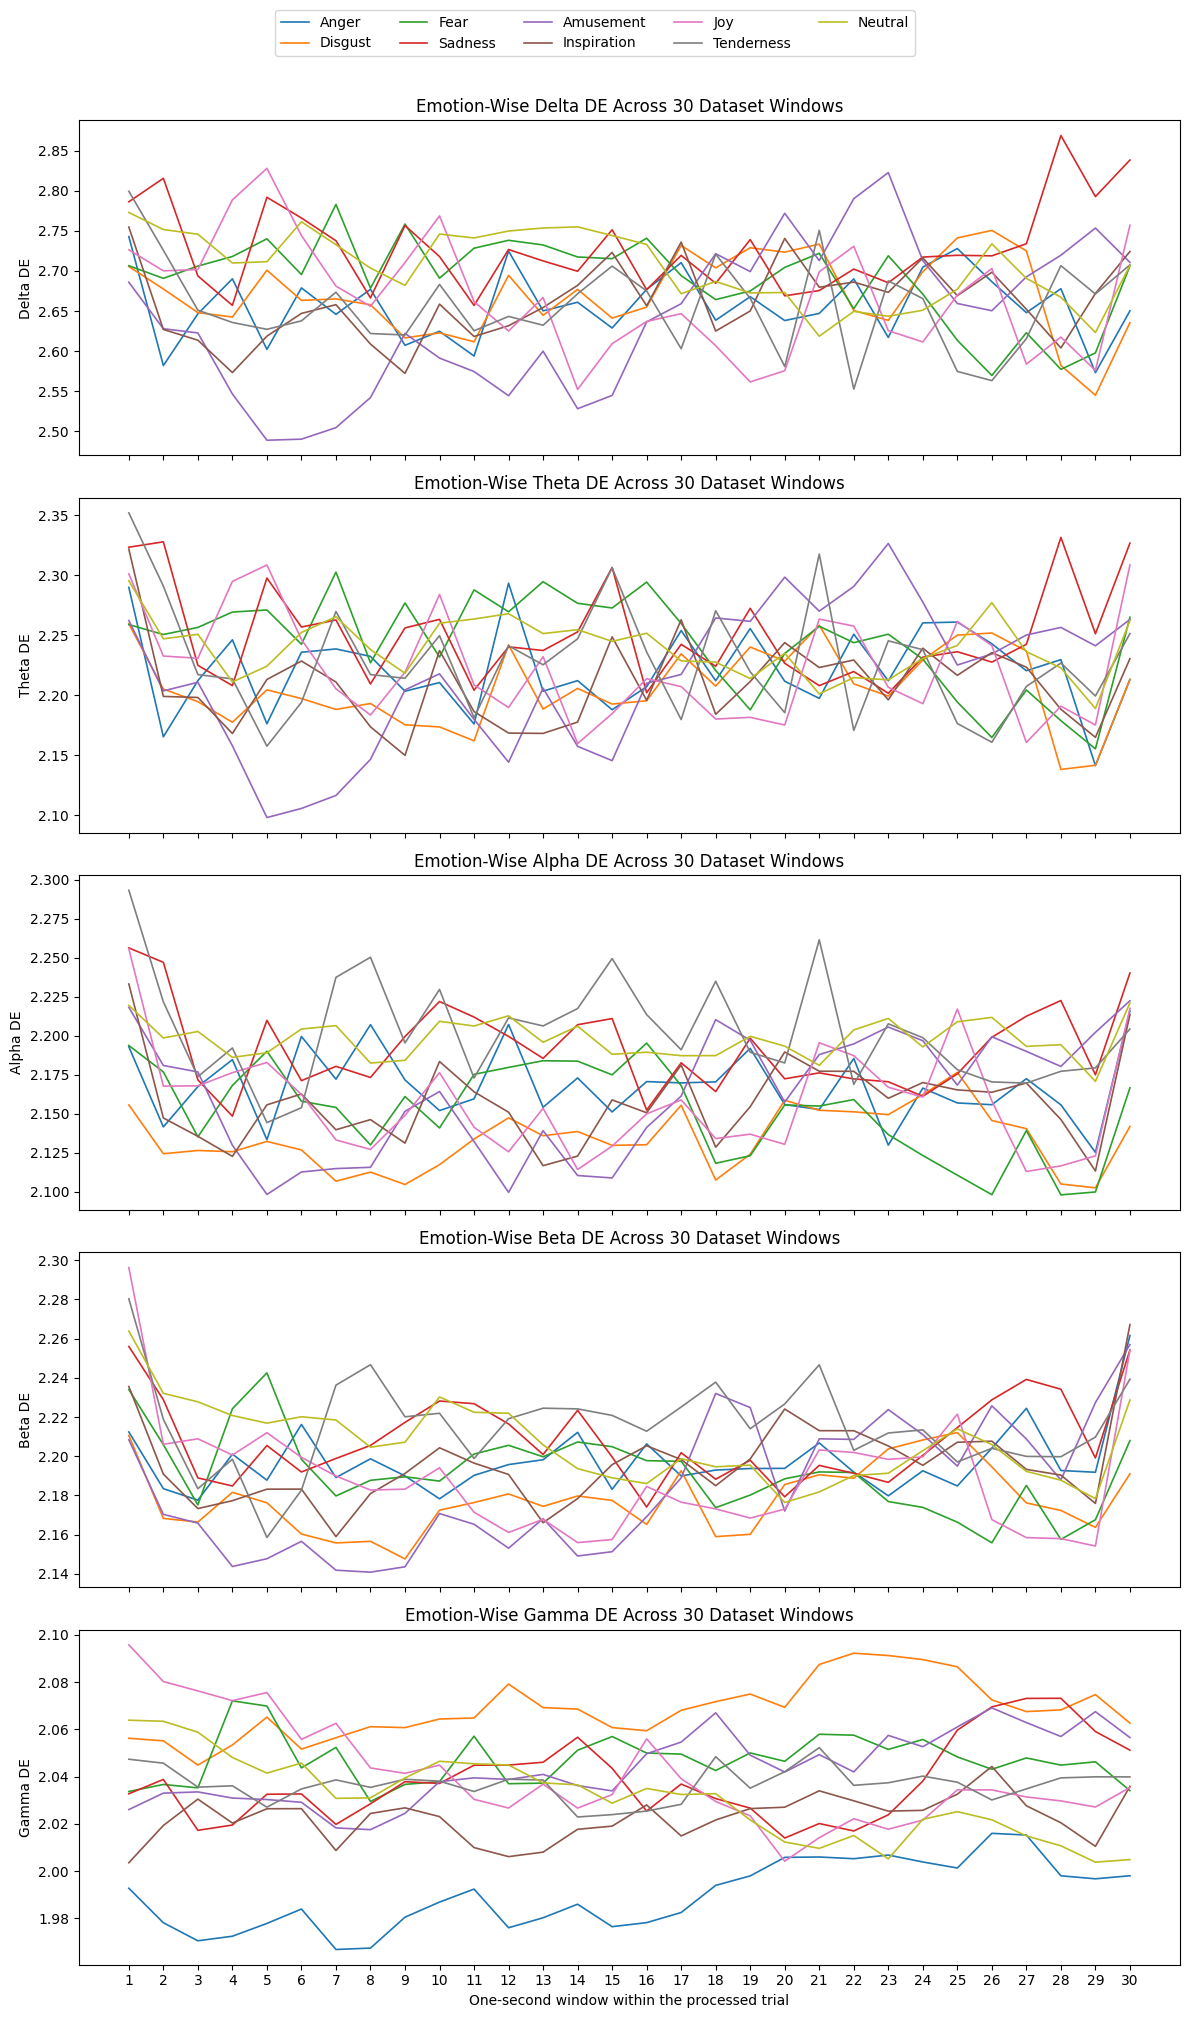

In [129]:
# Cell 61: Plot emotion-wise DE trajectories across actual dataset windows

emotion_windowwise_de = (
    secondwise_de_df
    .groupby([
        "Emotion",
        "Second",
    ])[FREQUENCY_BANDS]
    .mean()
    .reset_index()
    .sort_values([
        "Emotion",
        "Second",
    ])
)

fig, axes = plt.subplots(
    len(FREQUENCY_BANDS),
    1,
    figsize=(12, 20),
    sharex=True,
)

for axis, band in zip(
    axes,
    FREQUENCY_BANDS,
):
    for emotion in EXPECTED_EMOTIONS:
        emotion_data = (
            emotion_windowwise_de.loc[
                emotion_windowwise_de[
                    "Emotion"
                ] == emotion
            ]
            .sort_values("Second")
        )

        if len(emotion_data) != ACTUAL_DE_WINDOWS:
            raise ValueError(
                f"Emotion '{emotion}' contains "
                f"{len(emotion_data)} windows; "
                f"expected {ACTUAL_DE_WINDOWS}."
            )

        axis.plot(
            emotion_data["Second"],
            emotion_data[band],
            linewidth=1.2,
            label=emotion.title(),
        )

    axis.set_title(
        f"Emotion-Wise {band} DE Across "
        f"{ACTUAL_DE_WINDOWS} Dataset Windows"
    )

    axis.set_ylabel(
        f"{band} DE"
    )

axes[-1].set_xlabel(
    "One-second window within the processed trial"
)

axes[-1].set_xticks(
    actual_temporal_windows
)

handles, labels = (
    axes[0]
    .get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=5,
)

plt.tight_layout(
    rect=[0, 0, 1, 0.97]
)

plt.show()

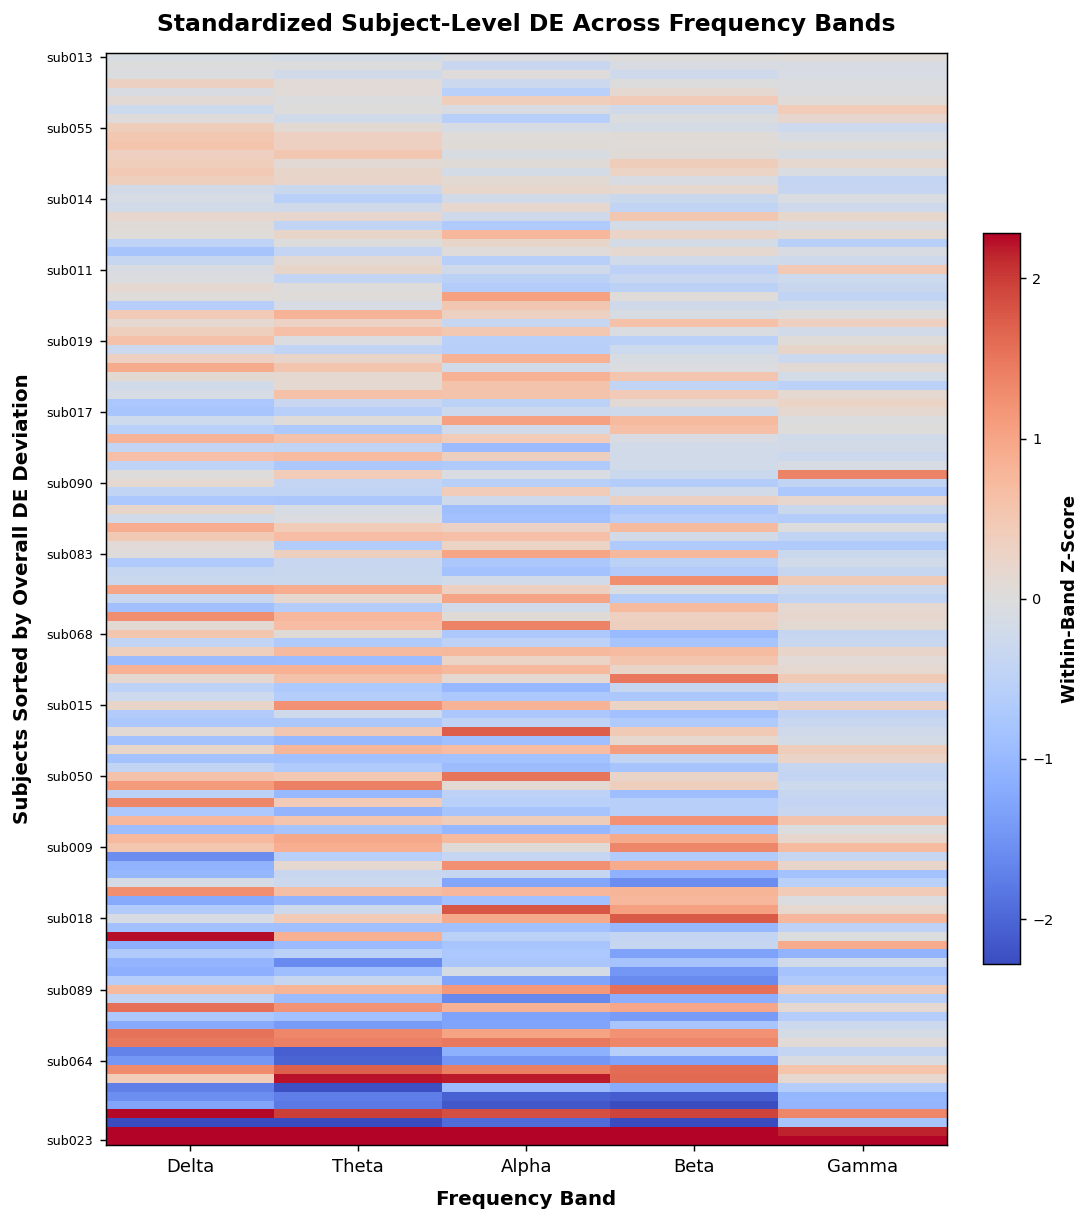

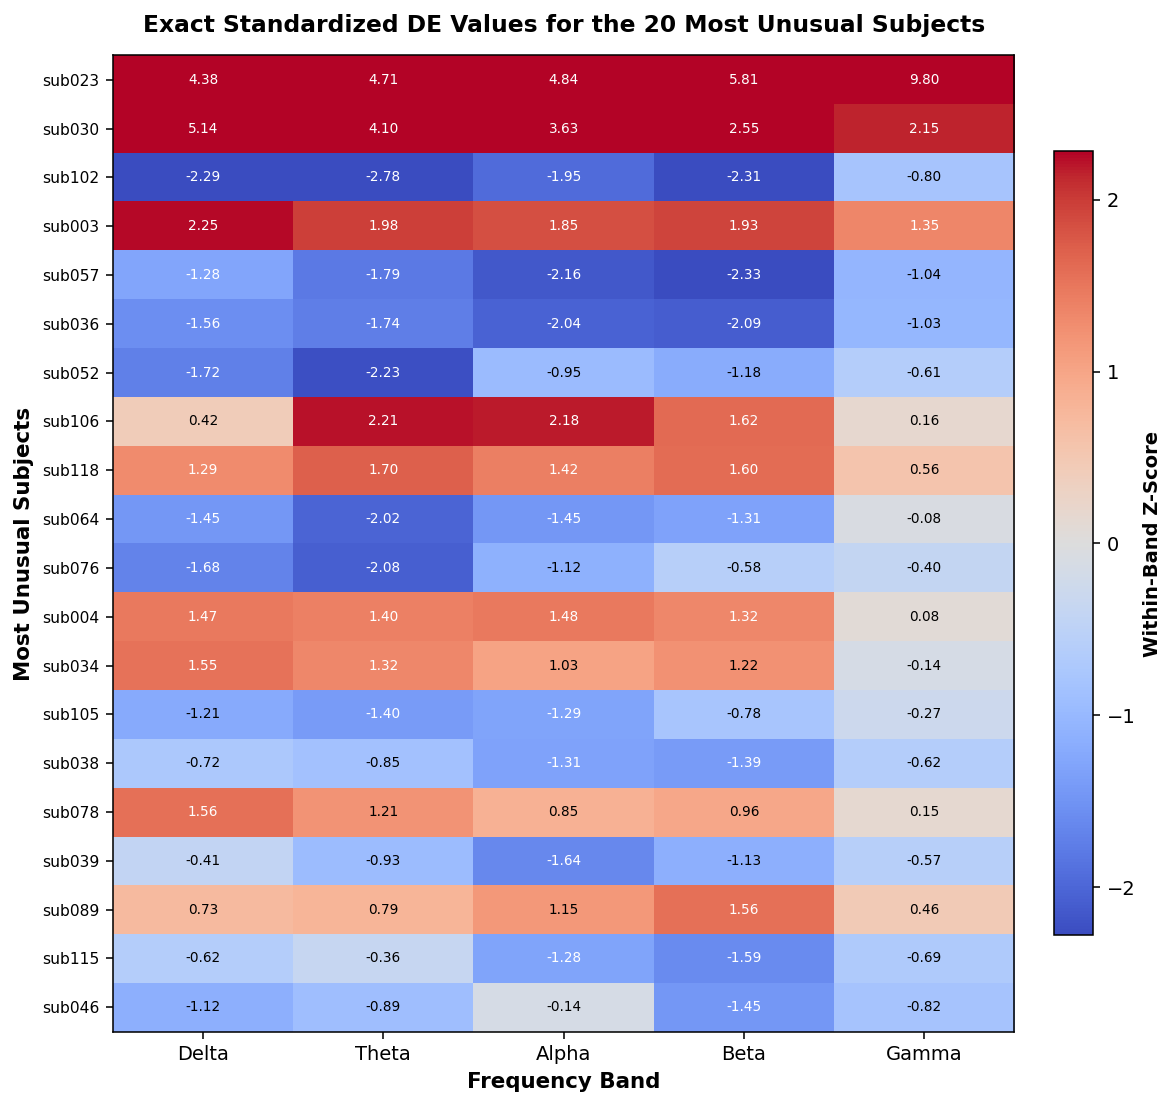

,Subject,Delta,Theta,Alpha,Beta,Gamma,Overall absolute z-score
0,sub023,4.383,4.709,4.841,5.809,9.800,5.908
1,sub030,5.144,4.099,3.628,2.551,2.150,3.514
2,sub102,-2.294,-2.785,-1.952,-2.306,-0.801,2.027
3,sub003,2.251,1.978,1.848,1.931,1.351,1.872
4,sub057,-1.283,-1.791,-2.157,-2.333,-1.041,1.721
5,sub036,-1.556,-1.742,-2.044,-2.086,-1.034,1.692
6,sub052,-1.718,-2.231,-0.949,-1.178,-0.614,1.338
7,sub106,0.420,2.211,2.183,1.619,0.161,1.319
8,sub118,1.291,1.697,1.423,1.596,0.561,1.314
9,sub064,-1.453,-2.017,-1.452,-1.312,-0.080,1.263


In [134]:
# Cell 62: Compact full heatmap plus readable annotated extreme-subject heatmap

subject_band_matrix = (
    de_subject_band_df
    .set_index("Subject")[FREQUENCY_BANDS]
    .sort_index()
    .copy()
)

assert not subject_band_matrix.empty, (
    "The subject-level DE table is empty."
)

assert subject_band_matrix.notna().all().all(), (
    "The subject-level DE table contains missing values."
)

assert np.isfinite(
    subject_band_matrix.values
).all(), (
    "The subject-level DE table contains non-finite values."
)


# ------------------------------------------------------------
# Standardize each band independently across subjects
# ------------------------------------------------------------

band_means = (
    subject_band_matrix.mean(axis=0)
)

band_stds = (
    subject_band_matrix.std(
        axis=0,
        ddof=0,
    )
)

if (band_stds == 0).any():
    zero_variance_bands = (
        band_stds[
            band_stds == 0
        ]
        .index
        .tolist()
    )

    raise ValueError(
        "Zero variance found in bands: "
        f"{zero_variance_bands}"
    )


subject_band_z = (
    subject_band_matrix
    - band_means
) / band_stds


overall_abs_z = (
    subject_band_z
    .abs()
    .mean(axis=1)
    .rename(
        "Overall absolute z-score"
    )
)


# Normal subjects first, most unusual subjects last.
sorted_subjects = (
    overall_abs_z
    .sort_values()
    .index
)

heatmap_values = (
    subject_band_z
    .loc[sorted_subjects]
)



colour_limit = float(
    np.nanpercentile(
        np.abs(
            heatmap_values.values
        ),
        98,
    )
)

colour_limit = min(
    max(
        colour_limit,
        2.0,
    ),
    3.0,
)

plot_values = (
    heatmap_values
    .clip(
        lower=-colour_limit,
        upper=colour_limit,
    )
)



number_of_subjects = len(
    plot_values
)

subject_tick_positions = np.unique(
    np.linspace(
        0,
        number_of_subjects - 1,
        min(16, number_of_subjects),
        dtype=int,
    )
)


fig, ax = plt.subplots(
    figsize=(8.5, 9.5),
    dpi=130,
)

image = ax.imshow(
    plot_values.values,
    aspect="auto",
    cmap="coolwarm",
    vmin=-colour_limit,
    vmax=colour_limit,
)

ax.set_xticks(
    np.arange(
        len(FREQUENCY_BANDS)
    )
)

ax.set_xticklabels(
    FREQUENCY_BANDS,
    fontsize=10,
)

ax.set_yticks(
    subject_tick_positions
)

ax.set_yticklabels(
    plot_values.index[
        subject_tick_positions
    ],
    fontsize=7,
)

ax.set_xlabel(
    "Frequency Band",
    fontsize=11,
    fontweight="bold",
    labelpad=8,
)

ax.set_ylabel(
    "Subjects Sorted by Overall DE Deviation",
    fontsize=11,
    fontweight="bold",
    labelpad=8,
)

ax.set_title(
    "Standardized Subject-Level DE Across Frequency Bands",
    fontsize=13,
    fontweight="bold",
    pad=12,
)

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.04,
    pad=0.04,
)

colorbar.set_label(
    "Within-Band Z-Score",
    fontsize=10,
    fontweight="bold",
)

colorbar.ax.tick_params(
    labelsize=8,
)

plt.tight_layout()
plt.show()


top_subject_count = min(
    20,
    len(subject_band_z),
)

top_subjects = (
    overall_abs_z
    .sort_values(
        ascending=False
    )
    .head(
        top_subject_count
    )
    .index
)

top_subject_values = (
    subject_band_z
    .loc[top_subjects]
)

top_subject_plot_values = (
    top_subject_values
    .clip(
        lower=-colour_limit,
        upper=colour_limit,
    )
)


fig, ax = plt.subplots(
    figsize=(8.5, 8),
    dpi=140,
)

image = ax.imshow(
    top_subject_plot_values.values,
    aspect="auto",
    cmap="coolwarm",
    vmin=-colour_limit,
    vmax=colour_limit,
)

ax.set_xticks(
    np.arange(
        len(FREQUENCY_BANDS)
    )
)

ax.set_xticklabels(
    FREQUENCY_BANDS,
    fontsize=10,
)

ax.set_yticks(
    np.arange(
        top_subject_count
    )
)

ax.set_yticklabels(
    top_subject_values.index,
    fontsize=8,
)

ax.set_xlabel(
    "Frequency Band",
    fontsize=11,
    fontweight="bold",
)

ax.set_ylabel(
    "Most Unusual Subjects",
    fontsize=11,
    fontweight="bold",
)

ax.set_title(
    "Exact Standardized DE Values for the 20 Most Unusual Subjects",
    fontsize=12,
    fontweight="bold",
    pad=12,
)


# Add exact values only where they remain readable.
for row_index in range(
    top_subject_count
):
    for column_index in range(
        len(FREQUENCY_BANDS)
    ):
        exact_value = float(
            top_subject_values.iloc[
                row_index,
                column_index,
            ]
        )

        displayed_value = float(
            top_subject_plot_values.iloc[
                row_index,
                column_index,
            ]
        )

        text_color = (
            "white"
            if abs(displayed_value)
            > colour_limit * 0.55
            else "black"
        )

        ax.text(
            column_index,
            row_index,
            f"{exact_value:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color=text_color,
        )


colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.04,
    pad=0.04,
)

colorbar.set_label(
    "Within-Band Z-Score",
    fontsize=10,
    fontweight="bold",
)

plt.tight_layout()
plt.show()


exact_value_table = (
    top_subject_values
    .join(
        overall_abs_z
    )
    .reset_index()
)


display(
    exact_value_table.style.format({
        **{
            band: "{:.3f}"
            for band in FREQUENCY_BANDS
        },
        "Overall absolute z-score": "{:.3f}",
    })
)

In [131]:
# Cell 63: Summarize candidate modeling units and class balance

number_of_subjects = len(
    processed_subjects
)

number_of_videos = len(
    video_mapping
)

number_of_windows = (
    ACTUAL_DE_WINDOWS
)

number_of_trials = (
    number_of_subjects
    * number_of_videos
)

number_of_window_observations = (
    number_of_trials
    * number_of_windows
)

emotion_video_counts = (
    video_mapping[
        "Emotion"
    ]
    .value_counts()
    .reindex(
        EXPECTED_EMOTIONS,
        fill_value=0,
    )
)


class_balance_df = pd.DataFrame({
    "Emotion": EXPECTED_EMOTIONS,
    "Videos": [
        int(
            emotion_video_counts.loc[
                emotion
            ]
        )
        for emotion in EXPECTED_EMOTIONS
    ],
})


class_balance_df[
    "Subject-video trials"
] = (
    class_balance_df[
        "Videos"
    ]
    * number_of_subjects
)


class_balance_df[
    "One-second window observations"
] = (
    class_balance_df[
        "Subject-video trials"
    ]
    * number_of_windows
)


class_balance_df[
    "Window proportion"
] = (
    class_balance_df[
        "One-second window observations"
    ]
    /
    class_balance_df[
        "One-second window observations"
    ].sum()
)


assert class_balance_df[
    "Videos"
].sum() == number_of_videos, (
    "Emotion-wise video counts do not sum to "
    "the total number of videos."
)


assert class_balance_df[
    "Subject-video trials"
].sum() == number_of_trials, (
    "Emotion-wise trial counts do not sum to "
    "the total number of trials."
)


assert class_balance_df[
    "One-second window observations"
].sum() == number_of_window_observations, (
    "Emotion-wise window counts do not sum to "
    "the total number of window observations."
)


display(
    class_balance_df.style.format({
        "Window proportion": "{:.2%}",
    })
)

,Emotion,Videos,Subject-video trials,One-second window observations,Window proportion
0,anger,3,369,11070,10.71%
1,disgust,3,369,11070,10.71%
2,fear,3,369,11070,10.71%
3,sadness,3,369,11070,10.71%
4,amusement,3,369,11070,10.71%
5,inspiration,3,369,11070,10.71%
6,joy,3,369,11070,10.71%
7,tenderness,3,369,11070,10.71%
8,neutral,4,492,14760,14.29%
